## Данные

In [285]:
# 0.1 Установка библиотек
import subprocess, sys
for pkg in ['requests', 'plotly', 'statsmodels', 'scikit-learn', 'lxml','mlflow', 'pyngrok']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])
from io import StringIO
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error


In [286]:
# 0.2
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import mlflow
import mlflow.sklearn

In [287]:
# 0.2.1 Инициализация MLflow (SQLite backend)
import os
DB_PATH = os.path.abspath("mlflow.db")
mlflow.set_tracking_uri(f"sqlite:///{DB_PATH}")
mlflow.set_experiment("nedra-sarimax-forecast")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")



MLflow tracking URI: sqlite:////content/mlflow.db


In [288]:
# 0.3
# Цвета для графиков
BLUE       = '#0055A5'
ACCENT     = '#E8702A'
BG_COLOR   = '#FFFFFF'
PLOT_BG    = '#F5F7FA'
FONT_COLOR = '#333333'
GRID_COLOR = '#D0D7E3'

In [289]:
# 0.4
def base_layout(title, height=500, margin=None, legend=None):
    m = margin or dict(l=160, r=40, t=90, b=80)
    lo = dict(
        title=dict(text=title, font=dict(size=16, color=BLUE,
                   family='Arial'), x=0.5, xanchor='center'),
        plot_bgcolor=PLOT_BG, paper_bgcolor=BG_COLOR,
        font=dict(family='Arial', size=12, color=FONT_COLOR),
        xaxis=dict(gridcolor=GRID_COLOR, zeroline=False),
        yaxis=dict(gridcolor=GRID_COLOR, zeroline=False),
        height=height, margin=m,
    )
    if legend is not None:
        lo['legend'] = legend
    return lo

def hbar(x_vals, y_labels, colors, text_vals=None, text_suffix=''):
    """Горизонтальная барная диаграмма (Plotly Bar, orientation=h)."""
    txt = text_vals if text_vals is not None else x_vals
    return go.Bar(
        x=x_vals, y=y_labels, orientation='h',
        marker_color=colors,
        text=[f'{v}{text_suffix}' for v in txt],
        textposition='outside', cliponaxis=False,
        hovertemplate='%{y}: %{x}<extra></extra>'
    )

In [290]:
# 0.5
# Загрузка данных
BGS_URL = 'https://ogcapi.bgs.ac.uk/collections/world-mineral-statistics/items'

# Перевод единиц в тонны
UNIT_TO_TONNES = {
    'tonnes': 1.0,
    'tonnes (metric)': 1.0,          # главный фикс: 1958 записей
    'tonnes (metal content)': 1.0,   # никель, медь: 337 записей
    'tonnes (al2o3 content)': 1.0,   # бокситы
    'tonnes (k2o content)': 1.0,     # калий
    'thousand tonnes': 1_000.0,
    'million tonnes': 1_000_000.0,
    'kilograms': 0.001,
    'kilograms (metal content)': 0.001,
    'kg': 0.001,
    'kt': 1_000.0,
    'mt': 1_000_000.0,
}

def fetch_bgs_production(target_year=None):
    """
    Загружает данные производства из BGS OGC-API Features.
    Если год не задан, определяет последний доступный год автоматически.
    """
    # Шаг 1: определяем последний доступный год
    if target_year is None:
        r = requests.get(BGS_URL, params={
            'f': 'json', 'limit': 20,
            'filter': 'bgs_statistic_type_trans = "Production"',
            'sortby': '-year'
        }, timeout=30)
        feats = r.json().get('features', [])
        years_found = sorted(
            set(int(f['properties']['year'][:4]) for f in feats),
            reverse=True
        )
        target_year = years_found[0] if years_found else 2023
        print(f"Последний доступный год в BGS: {target_year}")

    print(f"Загрузка данных BGS за {target_year} г.")
    all_features = []
    offset = 0
    limit = 5000

    while True:
        r = requests.get(BGS_URL, params={
            'f': 'json', 'limit': limit, 'offset': offset,
            'filter': (f'bgs_statistic_type_trans = "Production" '
                       f'AND year = "{target_year}-01-01"')
        }, timeout=90)

        data = r.json()
        features = data.get('features', [])
        all_features.extend(features)
        print(f"Получено: {len(all_features)} записей", end='\r')

        if len(features) < limit:
            break
        offset += limit

    print(f"\nВсего записей: {len(all_features)}")
    return all_features, target_year

raw_features, DATA_YEAR = fetch_bgs_production()

Последний доступный год в BGS: 2024
Загрузка данных BGS за 2024 г.
Получено: 2706 записей
Всего записей: 2706


In [291]:
# 0.6
# Обработка данных: нормализация единиц, агрегация по странам

records = []
for feat in raw_features:
    p = feat['properties']
    unit = (p.get('units') or '').lower().strip()
    qty  = p.get('quantity') or 0.0
    mult = UNIT_TO_TONNES.get(unit)
    if mult is None or qty <= 0:
        continue
    records.append({
        'country':    (p.get('country_trans') or ''),
        'iso3':       (p.get('country_iso3_code') or ''),
        'commodity':  (p.get('bgs_commodity_trans') or '').lower(),
        'erml_group': (p.get('erml_group') or ''),
        'qty_t':      qty * mult,
    })

df = pd.DataFrame(records)

# Тонны в миллионы тонн
df['qty_mt'] = df['qty_t'] / 1_000_000

# Суммарный объём добычи по странам
country_total = (df.groupby('country')['qty_mt'].sum()
                 .reset_index()
                 .rename(columns={'qty_mt': 'prod_mt'})
                 .sort_values('prod_mt', ascending=False)
                 .reset_index(drop=True))

print(f"Стран в датасете: {df['country'].nunique()}")
print(f"\nТОП-10 стран по объёму добычи ({DATA_YEAR} г., млн т):")
print(country_total.head(10).to_string(index=False))

TOP10 = country_total.head(10)['country'].tolist()
RUSSIA_NAMES = ['Russia', 'Russian Federation']

# ==== 1. Помесячная выручка Росатом Недра ====
# Если помесячки нет — раскладываем годовой rev_rub через сезонный профиль
months = pd.date_range('2015-01-01', '2025-12-01', freq='MS')
yearly = dict(zip(range(2015, 2026), rev_rub))  # rev_rub взят из ячейки r5F_1gp8WOhB

# Сезонный профиль горнодобычи: слабый Q1, пик Q4
season_weights = np.array([0.070,0.072,0.080,0.081,0.083,0.085,
                           0.084,0.085,0.086,0.089,0.091,0.094])
season_weights = season_weights / season_weights.sum()

rev_monthly = []
for m in months:
    base = yearly.get(m.year, np.nan)
    rev_monthly.append(base * season_weights[m.month - 1])
rev_m = pd.Series(rev_monthly, index=months, name='revenue_rub')

# ==== 2. Макро-признаки ====
import xml.etree.ElementTree as ET

def cbr_dynamic(val_nm_rq, start='01/01/2015', end='31/12/2025'):
    """Курс валюты по коду ЦБ, помесячное среднее."""
    url = "https://www.cbr.ru/scripts/XML_dynamic.asp"
    r = requests.get(url, params={
        'date_req1': start, 'date_req2': end, 'VAL_NM_RQ': val_nm_rq
    }, timeout=60)
    r.raise_for_status()
    root = ET.fromstring(r.text)
    rows = []
    for rec in root.findall('Record'):
        d = rec.attrib.get('Date')
        nom_el = rec.find('Nominal')
        val_el = rec.find('Value')
        if d is None or nom_el is None or val_el is None:
            continue
        nominal = float(nom_el.text.replace(',', '.'))
        value   = float(val_el.text.replace(',', '.'))
        rows.append((d, value / nominal))
    df = pd.DataFrame(rows, columns=['date', 'value'])
    df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
    return df.set_index('date')['value'].resample('MS').mean()

def get_key_rate(start='01/01/2015', end='31/12/2025'):
    """Ключевая ставка ЦБ РФ помесячно (последнее значение в месяце)."""
    key_rate_manual = {
        '2015-01-01': 17.0, '2015-02-01': 15.0, '2015-03-01': 14.0,
        '2015-05-01': 12.5, '2015-06-01': 11.5, '2015-08-01': 11.0,
        '2016-06-01': 10.5, '2016-09-01': 10.0,
        '2017-03-01': 9.75, '2017-04-01': 9.25, '2017-05-01': 9.0,
        '2017-09-01': 8.5,  '2017-10-01': 8.25, '2017-12-01': 7.75,
        '2018-02-01': 7.5,  '2018-03-01': 7.25, '2018-09-01': 7.5,
        '2018-12-01': 7.75,
        '2019-06-01': 7.5,  '2019-07-01': 7.25, '2019-09-01': 7.0,
        '2019-10-01': 6.5,  '2019-12-01': 6.25,
        '2020-02-01': 6.0,  '2020-04-01': 5.5,  '2020-06-01': 4.5,
        '2020-07-01': 4.25, '2021-03-01': 4.5,  '2021-04-01': 5.0,
        '2021-06-01': 5.5,  '2021-07-01': 6.5,  '2021-09-01': 6.75,
        '2021-10-01': 7.5,  '2021-12-01': 8.5,
        '2022-02-01': 9.5,  '2022-03-01': 20.0, '2022-04-01': 17.0,
        '2022-05-01': 14.0, '2022-06-01': 9.5,  '2022-07-01': 8.0,
        '2022-09-01': 7.5,  '2023-07-01': 8.5,  '2023-08-01': 12.0,
        '2023-09-01': 13.0, '2023-10-01': 15.0, '2023-12-01': 16.0,
        '2024-07-01': 18.0, '2024-10-01': 19.0, '2024-12-01': 21.0,
        '2025-06-01': 20.0, '2025-07-01': 18.0, '2025-09-01': 17.0,
        '2025-10-01': 16.5,
    }
    s = pd.Series(key_rate_manual).rename_axis('date').rename('key_rate')
    s.index = pd.to_datetime(s.index)
    s = s.sort_index().resample('MS').last()
    idx = pd.date_range('2015-01-01', '2025-12-01', freq='MS')
    return s.reindex(idx).ffill()

# Собственно вызовы:
usd = cbr_dynamic('R01235').rename('usd_rub')
eur = cbr_dynamic('R01239').rename('eur_rub')
cny = cbr_dynamic('R01375').rename('cny_rub')
key_rate = get_key_rate()

print('usd:',    usd.shape,    usd.head(2).to_dict(),    usd.tail(2).to_dict())
print('eur:',    eur.shape,    eur.head(2).to_dict(),    eur.tail(2).to_dict())
print('cny:',    cny.shape,    cny.head(2).to_dict(),    cny.tail(2).to_dict())
print('rate:',   key_rate.shape, key_rate.head(2).to_dict(), key_rate.tail(2).to_dict())
# ==== 3. Сборка датасета ====
# ==== 3. Сборка датасета ====
macro = pd.concat([usd, eur, cny, key_rate], axis=1).reindex(rev_m.index).ffill().bfill()
df_model = macro.copy()
df_model['revenue'] = rev_m

for col in ['usd_rub', 'eur_rub', 'cny_rub', 'key_rate']:
    df_model[f'{col}_lag1'] = df_model[col].shift(1)
    df_model[f'{col}_lag3'] = df_model[col].shift(3)
    df_model[f'{col}_ma3']  = df_model[col].rolling(3).mean()

df_model = df_model.iloc[3:].copy()
df_model = df_model.dropna(subset=['revenue', 'usd_rub', 'key_rate'])

print('df_model shape:', df_model.shape)
print(df_model[['usd_rub','key_rate','revenue']].head(3))
print(df_model[['usd_rub','key_rate','revenue']].tail(3))
df_model.to_csv('nedra_model_dataset.csv')

df_model = df_model.dropna()
df_model.to_csv('nedra_model_dataset.csv')
print(df_model.tail())

Стран в датасете: 173

ТОП-10 стран по объёму добычи (2024 г., млн т):
     country     prod_mt
       China 8428.830342
       India 1718.995458
   Australia 1600.001487
         USA 1586.670623
      Russia 1239.820135
   Indonesia  909.797058
      Brazil  761.795022
     Germany  602.672800
Saudi Arabia  552.815419
      Canada  425.877087
usd: (132,) {Timestamp('2015-01-01 00:00:00'): 65.1530875, Timestamp('2015-02-01 00:00:00'): 64.51817368421052} {Timestamp('2025-11-01 00:00:00'): 80.34382500000001, Timestamp('2025-12-01 00:00:00'): 78.40162272727274}
eur: (132,) {Timestamp('2015-01-01 00:00:00'): 75.3377125, Timestamp('2015-02-01 00:00:00'): 73.29496315789474} {Timestamp('2025-11-01 00:00:00'): 92.986945, Timestamp('2025-12-01 00:00:00'): 91.8711909090909}
cny: (132,) {Timestamp('2015-01-01 00:00:00'): 10.473504375000001, Timestamp('2015-02-01 00:00:00'): 10.31944} {Timestamp('2025-11-01 00:00:00'): 11.26246, Timestamp('2025-12-01 00:00:00'): 11.092818181818181}
rate: (132,) {T

In [292]:
# 0.7
# ==== Многолетняя панель BGS (2015–2024) ====
# Переиспользуем BGS_URL и UNIT_TO_TONNES из предыдущих ячеек.

def fetch_bgs_production_year(year):
    """Все записи Production за один календарный год."""
    feats, offset, limit = [], 0, 5000
    while True:
        r = requests.get(BGS_URL, params={
            'f': 'json', 'limit': limit, 'offset': offset,
            'filter': (f'bgs_statistic_type_trans = "Production" '
                       f'AND year = "{year}-01-01"')
        }, timeout=90)
        r.raise_for_status()
        batch = r.json().get('features', [])
        feats.extend(batch)
        if len(batch) < limit:
            break
        offset += limit
    return feats


def fetch_bgs_panel(start_year=2015, end_year=2024):
    """Панель 'страна × год' за диапазон лет (долго — ~1–2 мин)."""
    frames = []
    for y in range(start_year, end_year + 1):
        batch = fetch_bgs_production_year(y)
        print(f'  {y}: {len(batch)} записей')
        rows = []
        for feat in batch:
            p = feat['properties']
            unit = (p.get('units') or '').lower().strip()
            qty  = p.get('quantity') or 0.0
            mult = UNIT_TO_TONNES.get(unit)
            if mult is None or qty <= 0:
                continue
            rows.append({
                'country': p.get('country_trans') or '',
                'year':    int(p['year'][:4]),
                'qty_mt':  qty * mult / 1_000_000,
            })
        frames.append(pd.DataFrame(rows))
    return pd.concat(frames, ignore_index=True)


print('Загрузка панели BGS (2015–2024):')
panel = fetch_bgs_panel(2015, 2024)

# Унифицируем несколько вариантов имени России (для консистентности с RU_COUNTRIES)
panel['country'] = panel['country'].replace({
    'Russian Federation': 'Russia',
    'United States of America': 'USA',
    'United States': 'USA',
})

# Сводная матрица: страна × год
cy = panel.groupby(['country', 'year'])['qty_mt'].sum().unstack('year')
print(f'\nПанель: {cy.shape[0]} стран × {cy.shape[1]} лет')
print(f'Пропусков: {int(cy.isna().sum().sum())} '
      f'({cy.isna().sum().sum() / cy.size:.1%})')

Загрузка панели BGS (2015–2024):
  2015: 2670 записей
  2016: 2647 записей
  2017: 2665 записей
  2018: 2647 записей
  2019: 2672 записей
  2020: 2716 записей
  2021: 2717 записей
  2022: 2718 записей
  2023: 2717 записей
  2024: 2706 записей

Панель: 173 стран × 10 лет
Пропусков: 10 (0.6%)


In [293]:
# 0.8
# ==== Кластеризация траекторий стран ====

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

MIN_YEARS  = 8          # минимум лет с данными у страны
TOP_N      = 40         # ограничим топ-40 по средней добыче
USE_GROWTH = False      # False → индекс (год1=100); True → YoY log-growth

# 1) Оставляем страны с достаточной историей, затыкаем пропуски
cy_full = cy.dropna(thresh=MIN_YEARS).copy()
cy_full = cy_full.ffill(axis=1).bfill(axis=1)

# 2) Ограничим топ-N по среднему объёму
top = cy_full.mean(axis=1).nlargest(TOP_N).index
X_raw = cy_full.loc[top]

# 3) Признаки: форма траектории
if USE_GROWTH:
    X = np.log1p(X_raw).diff(axis=1).iloc[:, 1:].values
    feat_title = 'YoY log-прирост'
else:
    X = (X_raw.div(X_raw.iloc[:, 0], axis=0) * 100).values
    feat_title = 'Индекс (первый год = 100)'

# 4) Стандартизация + подбор k по silhouette
Xs = StandardScaler().fit_transform(X)
scores = {}
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xs)
    scores[k] = silhouette_score(Xs, km_k.labels_)
best_k = max(scores, key=scores.get)
print('Silhouette по k:',
      {k: round(v, 3) for k, v in scores.items()})
print(f'Оптимальное k = {best_k}')

# 5) Финальная модель
km = KMeans(n_clusters=best_k, n_init=50, random_state=42).fit(Xs)
labels = pd.Series(km.labels_, index=X_raw.index, name='cluster')

# 6) Содержимое кластеров
print('\nСостав кластеров:')
for c in sorted(labels.unique()):
    members = labels[labels == c].index.tolist()
    pretty = [RU_COUNTRIES.get(m, m) for m in members]
    head = ', '.join(pretty[:12]) + (' ...' if len(pretty) > 12 else '')
    print(f'  K{c} ({len(members)}): {head}')

Silhouette по k: {2: np.float64(0.894), 3: np.float64(0.324), 4: np.float64(0.337), 5: np.float64(0.294), 6: np.float64(0.248)}
Оптимальное k = 2

Состав кластеров:
  K0 (39): Китай, США, Австралия, Индия, Россия, Германия, Бразилия, Индонезия, Саудовская Аравия, Польша, Канада, Франция ...
  K1 (1): Гвинея


In [294]:
# 0.9
# ==== Spaghetti-plot: траектории стран, окрашенные по кластерам ====

palette = ['#0055A5', '#E8702A', '#27AE60', '#8E44AD',
           '#C0392B', '#16A085', '#D35400', '#2C3E50']
years_axis = X_raw.columns.tolist()

fig = go.Figure()
for c in sorted(labels.unique()):
    members = labels[labels == c].index.tolist()
    color = palette[c % len(palette)]

    # Отдельные страны кластера
    for i, country in enumerate(members):
        fig.add_trace(go.Scatter(
            x=years_axis, y=X_raw.loc[country].values,
            mode='lines',
            line=dict(color=color, width=1.6),
            opacity=0.7,
            legendgroup=f'c{c}', showlegend=False,
            hovertemplate=(f'<b>K{c} · {RU_COUNTRIES.get(country, country)}'
                           '</b><br>%{x}: %{y:.1f} млн т<extra></extra>'),
        ))

    # Центроид кластера
    centroid = X_raw.loc[members].mean(axis=0).values
    fig.add_trace(go.Scatter(
        x=years_axis, y=centroid,
        mode='lines+markers',
        line=dict(color=color, width=4),
        marker=dict(size=9, symbol='diamond',
                    line=dict(color='white', width=1)),
        name=f'K{c} · центроид (n={len(members)})',
        legendgroup=f'c{c}', showlegend=True,
        hovertemplate=f'K{c}<br>%{{x}}: %{{y:.1f}}<extra></extra>',
    ))

fig.update_layout(**base_layout(
    f'Кластеризация динамики добычи: {years_axis[0]}–{years_axis[-1]}<br>'
    f'<span style="font-size:12px;color:#666">'
    f'KMeans (k={best_k}) по {feat_title} · топ-{TOP_N} стран · '
    f'Источник: BGS World Mineral Production</span>',
    height=640, margin=dict(l=80, r=40, t=110, b=70),
))
fig.update_xaxes(title='Год')
fig.update_yaxes(title='Добыча, млн т')
fig.show()

In [295]:
# 0.10
# ДИАГНОСТИКА: какие единицы приходят из BGS?
all_units = {}
for feat in raw_features:
    p = feat['properties']
    unit = (p.get('units') or '').strip()
    qty  = p.get('quantity') or 0
    comm = (p.get('bgs_commodity_trans') or '')
    if unit not in all_units:
        all_units[unit] = {'n': 0, 'example': comm, 'total': 0}
    all_units[unit]['n'] += 1
    all_units[unit]['total'] += qty

print(f"{'✓/✗':<4} {'Единица':<40} {'Кол-во':<8} {'Пример товара'}")
print('-'*90)
for unit, info in sorted(all_units.items(), key=lambda x: -x[1]['total']):
    matched = unit.lower().strip() in UNIT_TO_TONNES
    mark = '✓' if matched else '✗'
    print(f"{mark:<4} {unit!r:<40} {info['n']:<8} {info['example'][:35]}")

✓/✗  Единица                                  Кол-во   Пример товара
------------------------------------------------------------------------------------------
✓    'tonnes (metric)'                        1958     bentonite and fuller's earth
✓    'kilograms'                              132      gold, mine
✓    'tonnes (Al2O3 content)'                 25       alumina
✗    'Carats'                                 27       diamond
✓    'tonnes (K2O content)'                   14       potash
✓    'tonnes (metal content)'                 337      nickel, mine
✓    'kilograms (metal content)'              112      silver, mine
✗    'million cubic metres'                   99       natural gas
✓    'thousand tonnes'                        2        


## Блок 1. Россия на карте мировой добычи

### 1.1. Топ-30 стран по объёму горнодобывающего производства (2024 г.)

In [296]:
# 1.1.0
RU_COUNTRIES = {
    'China': 'Китай', 'Australia': 'Австралия', 'Brazil': 'Бразилия',
    'India': 'Индия', 'Russia': 'Россия', 'Russian Federation': 'Россия',
    'Iran': 'Иран', 'Canada': 'Канада', 'USA': 'США',
    'United States': 'США', 'United States of America': 'США',
    'South Africa': 'ЮАР', 'Japan': 'Япония', 'Chile': 'Чили',
    'Congo, Democratic Republic': 'ДРК', 'Peru': 'Перу', 'Zambia': 'Замбия',
    'Indonesia': 'Индонезия', 'Ghana': 'Гана', 'Kazakhstan': 'Казахстан',
    'Uzbekistan': 'Узбекистан', 'Mexico': 'Мексика', 'Niger': 'Нигер',
    'Namibia': 'Намибия', 'Mongolia': 'Монголия', 'Bolivia': 'Боливия',
    'Argentina': 'Аргентина', 'Philippines': 'Филиппины',
    'Myanmar': 'Мьянма', 'Sweden': 'Швеция', 'Finland': 'Финляндия',
    'Germany': 'Германия', 'Norway': 'Норвегия', 'Ukraine': 'Украина',
    'New Caledonia': 'Нов. Каледония', 'Saudi Arabia': 'Саудовская Аравия',
    'North Korea': 'КНДР', 'Colombia': 'Колумбия', 'Pakistan': 'Пакистан',
    'United Kingdom': 'Великобритания', 'Czech Republic': 'Чехия',
    'Democratic Republic of the Congo': 'ДРК',
    'Madagascar': 'Мадагаскар', 'Malaysia': 'Малайзия', 'Vietnam': 'Вьетнам',
    'Poland': 'Польша',
    'Turkey': 'Турция',
    'France': 'Франция',
    'Spain': 'Испания',
    'Iraq': 'Ирак',
    'United Arab Emirates': 'ОАЭ',
    'Romania': 'Румыния',
    'Guinea': 'Гвинея',
    'Kuwait': 'Кувейт',
    'Korea (Rep. of)': 'Южная Корея',
    'Korea, Republic of': 'Южная Корея',
    'South Korea': 'Южная Корея',
    'Italy': 'Италия',
    'Iran (Islamic Republic of)': 'Иран',
}

In [297]:
# 1.1.1
top30 = country_total.head(30).sort_values('prod_mt', ascending=True)

# Перевод на русский (RU_COUNTRIES уже определён выше)
top30_ru = top30['country'].map(lambda c: RU_COUNTRIES.get(c, c))

colors30 = [ACCENT if c in RUSSIA_NAMES else BLUE
            for c in top30['country']]

fig1 = go.Figure(hbar(
    x_vals   = top30['prod_mt'].round(1).tolist(),
    y_labels = top30_ru.tolist(),
    colors   = colors30,
    text_vals= [f'{v:.0f}' for v in top30['prod_mt']],
    text_suffix=' млн т',
))

layout1 = base_layout(
    f'Топ-30 стран по объёму добычи полезных ископаемых ({DATA_YEAR} г.)<br>',
    height=780, margin=dict(l=175, r=120, t=110, b=60)
)
layout1['xaxis']['title'] = 'Суммарный объём добычи, млн т'
layout1['margin'] = dict(l=175, r=120, t=110, b=100)
fig1.update_layout(**layout1)

fig1.add_annotation(
    text=f'<b>Источник:</b> British Geological Survey (BGS), World Mineral Production {DATA_YEAR}. '
         'OGC API: ogcapi.bgs.ac.uk. '
         'Совокупный объём рассчитан по товарным группам, представленным в единицах массы.',
    xref='paper', yref='paper', x=0.5, y=-0.11,
    showarrow=False, font=dict(size=8, color='#666666'), xanchor='center'
)

fig1.show()

**Что показывает график:**
Рейтинг топ-30 стран мира по совокупному объёму горнодобывающего производства в 2024 г. (млн т, все виды полезных ископаемых в единицах массы). Россия выделена оранжевым.

**Ключевые выводы:**
- Россия занимает 5 место в мире с объёмом добычи 1 239,8 млн т (2024 г.)
- Лидер - Китай (8 428 млн т), опережает Россию в 6,8 раза
- Россия входит в тройку крупнейших несырьевых (non-China/India) горнодобывающих держав наряду с Австралией и США
- Позиция подтверждает стратегическое значение российской горнодобывающей отрасли в глобальном масштабе

**Источник:** [British Geological Survey (BGS), World Mineral Production 2024](https://www.bgs.ac.uk/mineralsuk/statistics/worldStatistics.html) · [OGC API](https://ogcapi.bgs.ac.uk/collections/world-mineral-statistics/items) Совокупный объём рассчитан по товарным группам в единицах массы (исключены баррели нефти, кубометры газа, каратов алмазов).

### 1.2. Топ-10 по ключевым видам стратегического сырья (2024 г.)

In [298]:
# 1.2.1
print(country_total.head(10).to_string(index=False))

     country     prod_mt
       China 8428.830342
       India 1718.995458
   Australia 1600.001487
         USA 1586.670623
      Russia 1239.820135
   Indonesia  909.797058
      Brazil  761.795022
     Germany  602.672800
Saudi Arabia  552.815419
      Canada  425.877087


In [299]:
# 1.2.2
STRATEGIC = {
    'Уголь':  lambda d: d['commodity'].str.lower().str.contains('coal', na=False),
    'Железо': lambda d: d['commodity'].str.lower().str.contains('iron', na=False),
    'Медь':   lambda d: d['erml_group'].str.lower().str.contains('copper', na=False),
    'Золото': lambda d: d['erml_group'].str.lower().str.contains('gold', na=False),
    'Никель': lambda d: d['erml_group'].str.lower().str.contains('nickel', na=False),
    'Уран':   lambda d: d['commodity'].str.lower().str.contains('uranium', na=False),
    'РЗМ':    lambda d: (d['erml_group'].str.lower().str.contains('rare earth', na=False) |
                         d['commodity'].str.lower().str.contains('rare earth', na=False)),
}


fig2 = make_subplots(
    rows=4, cols=2,
    subplot_titles=list(STRATEGIC.keys()),
    horizontal_spacing=0.18,
    vertical_spacing=0.08,
)

for idx, (label, flt_fn) in enumerate(STRATEGIC.items()):
    row, col = divmod(idx, 2)
    subset = df[flt_fn(df)]
    top10_raw = (subset.groupby('country')['qty_mt'].sum()
                 .nlargest(10).sort_values(ascending=True))

    if top10_raw.empty:
        continue

    # Авто-выбор единицы отображения
    max_val = top10_raw.values.max()
    if max_val < 0.01:
        display_vals = top10_raw.values * 1_000_000
        unit = 'т'
    elif max_val < 1:
        display_vals = top10_raw.values * 1_000
        unit = 'тыс. т'
    else:
        display_vals = top10_raw.values
        unit = 'млн т'

    ru_labels = [RU_COUNTRIES.get(c, c) for c in top10_raw.index]
    clrs = [ACCENT if RU_COUNTRIES.get(c, c) == 'Россия' else BLUE
            for c in top10_raw.index]

    fmt = [f'{v:,.0f}' if v >= 100 else (f'{v:.1f}' if v >= 1 else f'{v:.2f}')
           for v in display_vals]

    fig2.add_trace(
        go.Bar(x=display_vals, y=ru_labels, orientation='h',
               marker_color=clrs,
               text=[f'{f} {unit}' for f in fmt],
               textposition='outside', cliponaxis=False,
               showlegend=False,
               hovertemplate=f'%{{y}}: %{{x:,.1f}} {unit}<extra></extra>'),
        row=row+1, col=col+1
    )

fig2.update_layout(
    title=dict(
        text=(f'Топ-10 стран по стратегическим и критическим видам сырья ({DATA_YEAR} г.)<br>'
              '<span style="font-size:12px;color:#666">Объём добычи · '
              'Источник: <a href="https://www.bgs.ac.uk/mineralsuk/statistics/worldStatistics.html">BGS World Mineral Production</a> · Оранжевым — Россия</span>'),
        font=dict(size=16, color=BLUE, family='Arial'),
        x=0.5, xanchor='center'),
    plot_bgcolor=PLOT_BG, paper_bgcolor=BG_COLOR,
    font=dict(family='Arial', size=10, color=FONT_COLOR),
    height=1400, margin=dict(l=130, r=90, t=110, b=60),
)
for ax in fig2.layout:
    if ax.startswith('xaxis'):
        fig2.layout[ax].update(gridcolor=GRID_COLOR, zeroline=False, tickformat=',')
    if ax.startswith('yaxis'):
        fig2.layout[ax].update(gridcolor=GRID_COLOR, zeroline=False)

fig2.show()

**Что показывают графики:**
Топ-10 стран по добыче 7 стратегических видов сырья: уголь, железо, медь, золото, никель, уран, РЗМ (редкоземельные металлы).

**Ключевые выводы:**
- **Уголь:** Китай и Индия вместе обеспечивают более 70% мировой добычи, Россия входит в пятёрку лидеров
- **Никель:** Индонезия - лидер, Россия (Норникель) удерживает позиции в мировой пятёрке
- **Золото:** Россия входит в тройку крупнейших производителей
- **Уран:** Казахстан - мировой лидер, Россия присутствует в нескольких крупных юрисдикциях через Росатом
- **РЗМ:** Китай контролирует >60% мировой добычи, что является критической концентрацией для глобальных цепочек поставок

**Источник:** [British Geological Survey (BGS), World Mineral Production 2024](https://www.bgs.ac.uk/mineralsuk/statistics/worldStatistics.html) · [OGC API](https://ogcapi.bgs.ac.uk/collections/world-mineral-statistics/items)

### 1.3. Доля топ-10 стран в мировой добыче по видам сырья (2024 г.)

In [300]:
# 1.3.1
STRATEGIC_HEAT = {
    'Уголь':  lambda d: d['commodity'].str.lower().str.contains('coal', na=False),
    'Железо': lambda d: d['commodity'].str.lower().str.contains('iron', na=False),
    'Медь':   lambda d: d['erml_group'].str.lower().str.contains('copper', na=False),
    'Золото': lambda d: d['erml_group'].str.lower().str.contains('gold', na=False),
    'Никель': lambda d: d['erml_group'].str.lower().str.contains('nickel', na=False),
    'Уран':   lambda d: d['commodity'].str.lower().str.contains('uranium', na=False),
    'РЗМ':    lambda d: (d['erml_group'].str.lower().str.contains('rare earth', na=False) |
                         d['commodity'].str.lower().str.contains('rare earth', na=False)),
}

# Доля топ-10 стран в мировом производстве каждого вида
heat_data = {}
for label, flt_fn in STRATEGIC_HEAT.items():
    subset = df[flt_fn(df)]
    world_total = subset['qty_mt'].sum()
    if world_total == 0:
        continue
    top10_shares = (subset[subset['country'].isin(TOP10)]
                    .groupby('country')['qty_mt'].sum()
                    / world_total * 100)
    heat_data[label] = top10_shares

heat_df = pd.DataFrame(heat_data).reindex(TOP10).fillna(0)

# Названия стран на русский
heat_df.index = [RU_COUNTRIES.get(c, c) for c in heat_df.index]


ru_idx = [i for i, c in enumerate(heat_df.index) if c == 'Россия']
other_idx = [i for i, c in enumerate(heat_df.index) if c != 'Россия']
heat_df = heat_df.iloc[ru_idx + other_idx]

fig3 = go.Figure(go.Heatmap(
    z=heat_df.values,
    x=heat_df.columns.tolist(),
    y=heat_df.index.tolist(),
    colorscale=[
        [0.0, '#EEF2F8'],
        [0.3, '#6FA3D8'],
        [0.6, '#0055A5'],
        [1.0, '#003070'],
    ],
    zmin=0, zmax=60,
    text=[[f'{v:.1f}%' if v > 0.5 else ('—' if v == 0 else f'{v:.1f}%')
           for v in row] for row in heat_df.values],
    texttemplate='%{text}',
    hovertemplate='%{y} · %{x}: %{z:.1f}%<extra></extra>',
    showscale=True,
    colorbar=dict(title='Доля, %', thickness=14, len=0.9),
))

# Рамка вокруг строки России
for i, country in enumerate(heat_df.index):
    if country == 'Россия':
        fig3.add_shape(type='rect',
            x0=-0.5, x1=len(heat_df.columns)-0.5,
            y0=i-0.5, y1=i+0.5,
            line=dict(color=ACCENT, width=2.5))

fig3.update_layout(**base_layout(
    f'Доля топ-10 стран в мировой добыче по видам сырья ({DATA_YEAR} г.)<br>'
    '<span style="font-size:12px;color:#666">% от мирового объёма добычи · '
    f'Источник: BGS World Mineral Production {DATA_YEAR}</span>',
    height=420,
    margin=dict(l=130, r=80, t=110, b=60),
))
fig3.show()

**Что показывает тепловая карта:**
Доля топ-10 горнодобывающих стран в мировом производстве по каждому из 7 стратегических видов сырья. Чем темнее ячейка, тем выше доля страны в мировой добыче.

**Ключевые выводы:**
- Россия занимает значимые позиции по углю, никелю и золоту, однако её доля в РЗМ минимальна
- Китай доминирует в РЗМ и угле, стратегическая зависимость мирового рынка от одной страны
- По урану в тепловую карту входят иные страны (Казахстан, Канада, Намибия), топ-10 по общей добыче не совпадает с лидерами уранодобычи
- Диверсификация сырьевого портфеля России (уголь, золото, никель, уран) снижает риск зависимости от одного рынка

**Источник:** [British Geological Survey (BGS), World Mineral Production 2024](https://www.bgs.ac.uk/mineralsuk/statistics/worldStatistics.html) · [OGC API](https://ogcapi.bgs.ac.uk/collections/world-mineral-statistics/items)

## Блок 2. Финансовые показатели ведущих горнодобывающих компаний мира (2025 г.)

### 2.1. Выручка ведущих горнодобывающих компаний (2025 г.)

In [301]:
# 2.1.1
ROSATOM_NEDRA_COLOR = '#27AE60'

def comp_color(name):
    if name == 'АО «Росатом Недра»\n(Россия)':
        return ROSATOM_NEDRA_COLOR
    elif name == 'Норильский Никель\n(Россия)':
        return ACCENT
    else:
        return BLUE

COMP_NAMES = [
    'АО «Росатом Недра»\n(Россия)',
    'PT Bukit Asam\n(Индонезия)',
    'K+S AG\n(Германия)',
    "Ma'aden\n(Саудовская Аравия)",
    'Agnico Eagle\n(Канада)',
    'Норильский Никель\n(Россия)',
    'Coal India\n(Индия)',
    'Newmont\n(США)',
    'Vale\n(Бразилия)',
    'Zijin Mining\n(Китай)',
    'BHP\n(Австралия)',
]

# Выручка 2025
COMP_REV = [0.96, 2.6, 4.0, 10.3, 11.9, 13.8, 16.8, 22.7, 38.4, 49.7, 51.3]

# EBITDA 2025
COMP_EB  = [0.25, 0.31, 0.67,  4.3,  8.1,  5.7,  6.1, 13.5, 15.5, 14.3, 26.0]

# CAPEX 2025
COMP_CX  = [0.33, 0.20, 0.60,  1.8,  2.1,  2.6,  2.6,  3.0,  5.5,  6.0,  9.8]

# Список цветов для каждой компании
comp_clrs = [comp_color(n) for n in COMP_NAMES]

Среднегодовой курс ЦБ РФ 2025, kursvaliut.ru

In [302]:
# 2.1.2 Выручка компаний
fig_cr = go.Figure(hbar(COMP_REV, COMP_NAMES, comp_clrs, text_suffix=' $млрд'))
lo_cr = base_layout(
    'Выручка ведущих горнодобывающих компаний (2025 г.)<br>'
    '<span style="font-size:12px">Источник: Годовые отчёты компаний 2025 г. · '
    'Отбор: PwC Mine 2026</span>',
    height=560, margin=dict(l=200, r=100, t=100, b=130)
)
lo_cr['xaxis']['title'] = 'Выручка, $млрд'
fig_cr.update_layout(**lo_cr)
fig_cr.add_annotation(
    text=(
        'АО «Росатом Недра» - внутренняя отчётность 2025 г., конвертация по курсу ЦБ РФ 83.21 руб/$. '
        'Coal India - FY2024-25, INR/USD 85.3. K+S AG - EUR/USD 1.09. '
        'PT Bukit Asam - IDR/USD 16,300. BHP - FY2025 (июль 2024-июнь 2025). '
        'Agnico Eagle - PwC Mine 2026 #6. Newmont - PwC Mine 2026 #5.'
    ),
    xref='paper', yref='paper', x=0.5, y=-0.21,
    showarrow=False, font=dict(size=8, color='#666666'), xanchor='center'
)
fig_cr.show()

**Что показывает график:** Рейтинг ведущих горнодобывающих компаний мира по выручке за 2025 г. (в млрд долл. США). Позволяет оценить масштаб бизнеса и рыночную позицию АО «Росатом Недра» относительно глобальных лидеров отрасли.

**Ключевые выводы:**
Тройка лидеров по выручке: BHP (Австралия) - 51,3 млрд, Zijin Mining (Китай) - 49,7 млрд, Vale (Бразилия) - 38,4 млрд. АО «Росатом Недра» с выручкой $0,96 млрд замыкает рейтинг, уступая лидеру более чем в 50 раз. Несмотря на значительный рост выручки в рублях (+275% с 2015 г.), в долларовом эквиваленте компания остаётся небольшим игроком на фоне глобальных конкурентов.

### 2.2. EBITDA ведущих горнодобывающих компаний (2025 г.)

In [303]:
# 2.2.1
eb_order = sorted(zip(COMP_EB, COMP_NAMES), key=lambda x: x[0])
eb_cv, eb_cn = zip(*eb_order)
eb_cc = [comp_color(c) for c in eb_cn]

fig_ceb = go.Figure(hbar(list(eb_cv), list(eb_cn), list(eb_cc), text_suffix=' $млрд'))
lo_ceb = base_layout(
    'EBITDA ведущих горнодобывающих компаний (2025 г.)<br>'
    '<span style="font-size:12px">Источник: Годовые отчёты компаний 2025 г.</span>',
    height=560, margin=dict(l=200, r=100, t=100, b=80)
)
lo_ceb['xaxis']['title'] = 'EBITDA, $млрд'
fig_ceb.update_layout(**lo_ceb)
fig_ceb.show()

**Что показывает график:** EBITDA (операционная прибыль до вычета амортизации) ведущих горнодобывающих компаний за 2025 г. - ключевой показатель операционной эффективности бизнеса.

**Ключевые выводы:**
Наибольшую операционную прибыль генерируют BHP (26,0 млрд), Vale (15,5 млрд) и Zijin Mining (14,3 млрд).
EBITDA АО «Росатом Недра» - 0,25 млрд, что соответствует уровню наименее крупных участников рейтинга.
Разрыв с лидером (BHP) составляет более 100 раз, что указывает на существенный потенциал роста операционной прибыльности.

### 2.3. CAPEX ведущих горнодобывающих компаний (2025 г.)

In [304]:
# 2.3.1
cx_order = sorted(zip(COMP_CX, COMP_NAMES), key=lambda x: x[0])
cx_cv, cx_cn = zip(*cx_order)
cx_cc = [comp_color(c) for c in cx_cn]

fig_ccx = go.Figure(hbar(list(cx_cv), list(cx_cn), list(cx_cc), text_suffix=' $млрд'))
lo_ccx = base_layout(
    'Капитальные затраты (CAPEX) ведущих горнодобывающих компаний (2025 г.)<br>'
    '<span style="font-size:12px">Источник: Годовые отчёты компаний 2025 г.</span>',
    height=560, margin=dict(l=200, r=100, t=100, b=80)
)
lo_ccx['xaxis']['title'] = 'CAPEX, $млрд'
fig_ccx.update_layout(**lo_ccx)
fig_ccx.show()

**Что показывает график:** Капитальные затраты (CAPEX) ведущих горнодобывающих компаний в 2025 г. — объём инвестиций в развитие и поддержание производственных активов.

**Ключевые выводы:**
Крупнейшие инвесторы в инфраструктуру: BHP (9,8 млрд), Vale (5,5 млрд), Zijin Mining (6,0 млрд).
АО «Росатом Недра» вложила 0,33 млрд - относительно высокий показатель для компании данного масштаба.
Высокая доля CAPEX в структуре затрат Росатом Недра свидетельствует об активной фазе развития и расширения производственной базы.

### 2.4. CAPEX/EBITDA ведущих горнодобывающих компаний (2025 г.)

In [305]:
# 2.4.1
import operator
cx_eb_ratio = [round(eb/cx*100, 1) for cx, eb in zip(COMP_CX, COMP_EB)]
ratio_order = sorted(zip(cx_eb_ratio, COMP_NAMES), key=operator.itemgetter(0))
r_vals, r_names = zip(*ratio_order)
r_clrs = [comp_color(c) for c in r_names]

fig_ratio = go.Figure(hbar(list(r_vals), list(r_names), list(r_clrs), text_suffix='%'))
lo_r = base_layout(
    'Коэффициент EBITDA/CAPEX: эффективность капитальных вложений (2025 г.)<br>'
    '<span style="font-size:12px">EBITDA ÷ CAPEX × 100% · Источник: Годовые отчёты 2025 г. · <a href="https://www.pwc.com/gx/en/energy-utilities-mining/publications/mine.html">PwC Mine 2026</a></span>',
    height=560, margin=dict(l=200, r=80, t=100, b=80)
)
lo_r['xaxis']['title'] = 'EBITDA / CAPEX, %'
fig_ratio.update_layout(**lo_r)
fig_ratio.show()

**Что показывает график:** Коэффициент EBITDA/CAPEX - соотношение операционной прибыли к капитальным вложениям. Чем выше значение, тем эффективнее компания генерирует прибыль на каждый вложенный в развитие доллар.

**Ключевые выводы:**
Наиболее эффективны по данному показателю Coal India (238%), Zijin Mining (238%) и Agnico Eagle (386%).
АО «Росатом Недра» демонстрирует коэффициент ниже 100%, что означает: CAPEX превышает EBITDA, компания инвестирует активнее, чем зарабатывает операционной прибыли.
Это характерно для компаний в фазе активного роста и расширения, когда инвестиции опережают текущую доходность.

### 2.5. EBITDA-маржа ведущих горнодобывающих компаний (2025 г.)

In [306]:
# 2.5.1
eb_margin = [round(eb/rev*100, 1) for eb, rev in zip(COMP_EB, COMP_REV)]
marg_order = sorted(zip(eb_margin, COMP_NAMES), key=operator.itemgetter(0))
m_vals, m_names = zip(*marg_order)
m_clrs = [comp_color(c) for c in m_names]

fig_marg = go.Figure(hbar(list(m_vals), list(m_names), list(m_clrs), text_suffix='%'))
lo_m = base_layout(
    'EBITDA-маржа ведущих горнодобывающих компаний (2025 г.)<br>'
    '<span style="font-size:12px">EBITDA ÷ Выручка × 100% · Источник: Годовые отчёты 2025 г. · <a href="https://www.pwc.com/gx/en/energy-utilities-mining/publications/mine.html">PwC Mine 2026</a></span>',
    height=560, margin=dict(l=200, r=80, t=100, b=80)
)
lo_m['xaxis']['title'] = 'EBITDA-маржа, %'
fig_marg.update_layout(**lo_m)
fig_marg.show()

**Что показывает график:** EBITDA-маржа (EBITDA / Выручка × 100%) — показатель рентабельности, отражающий, какую долю выручки компания конвертирует в операционную прибыль.

**Ключевые выводы:**
Наиболее рентабельны Agnico Eagle (68,1%), Ma'aden (41,7%) и BHP (50,7%) — компании с высокой долей ценных металлов и эффективной структурой затрат. EBITDA-маржа АО «Росатом Недра» составляет 26,2%, что находится в нижней части рейтинга, однако соответствует среднеотраслевым значениям для диверсифицированных горнодобывающих компаний.
Рост маржи является одним из ключевых приоритетов для повышения инвестиционной привлекательности компании.

## Блок 3. Инвестиции в технологии и цифровизацию (2025 г.)

In [307]:
# 3.1
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Планы по инвестициям в цифровизацию (2026 г.)',
        'Статус внедрения цифровых технологий'
    )
)

# планы на 2026
labels_plans  = ['Снизить', 'Сохранить', 'Увеличить']
values_plans  = [27, 49, 24]
colors_plans  = ['#C0392B', '#95A5A6', BLUE]

fig.add_trace(go.Bar(
    x=labels_plans,
    y=values_plans,
    marker_color=colors_plans,
    text=[f'{v}%' for v in values_plans],
    textposition='outside',
    textfont=dict(size=13, color=FONT_COLOR),
    showlegend=False
), row=1, col=1)

# статус внедрения
labels_impl = ['Фрагментарно\nили тестово', 'Системное\nвнедрение']
values_impl = [81, 19]
colors_impl = ['#C0392B', BLUE]

fig.add_trace(go.Bar(
    x=labels_impl,
    y=values_impl,
    marker_color=colors_impl,
    text=[f'{v}%' for v in values_impl],
    textposition='outside',
    textfont=dict(size=13, color=FONT_COLOR),
    showlegend=False
), row=1, col=2)

fig.update_layout(
    title=dict(
        text='Цифровизация горнодобывающих компаний России',
        font=dict(size=16, color=FONT_COLOR, family='Arial'),
        x=0.5
    ),
    paper_bgcolor=BG_COLOR,
    plot_bgcolor=PLOT_BG,
    font=dict(color=FONT_COLOR, size=12, family='Arial'),
    height=500,
    margin=dict(t=100, b=130, l=60, r=40)
)

fig.update_yaxes(
    range=[0, 100],
    ticksuffix='%',
    gridcolor=GRID_COLOR
)

fig.add_annotation(
    text='56% российских горнодобывающих компаний тратят на цифровизацию менее 2% от выручки',
    xref='paper', yref='paper',
    x=0.5, y=-0.15,
    showarrow=False,
    font=dict(size=11, color='#C0392B'),
    xanchor='center'
)

fig.add_annotation(
    text='Источник: Kept и ГК «Цифра», апрель 2026 г.',
    xref='paper', yref='paper',
    x=0.5, y=-0.25,
    showarrow=False,
    font=dict(size=9, color='#888888'),
    xanchor='center'
)

fig.show()

**Что показывает:** уровень цифровизации и инвестиционные планы российских горнодобывающих компаний на 2026 год.

**Вывод:** Картина контрастирует с мировыми лидерами:
- **81%** компаний внедряют технологии лишь фрагментарно или в тестовом режиме
- **56%** тратят на цифровизацию менее 2% от выручки
- **27%** планируют снизить расходы на цифровые технологии в 2026 году
- Только 5% готовы инвестировать в новые масштабные инициативы

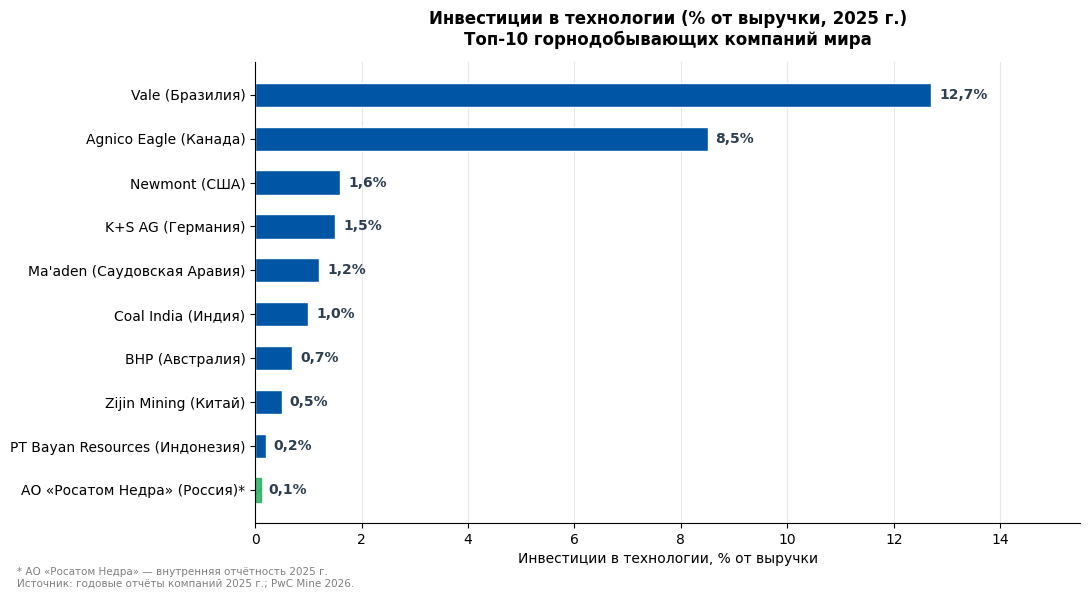

In [308]:
# 3.2
%matplotlib inline
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import matplotlib.pyplot as plt
from IPython.display import display

BLUE                = '#0055A5'
ACCENT              = '#E8702A'
ROSATOM_NEDRA_COLOR = '#27AE60'
LIGHT_GRAY          = '#BDC3C7'

companies = [
    'Vale (Бразилия)',
    'Agnico Eagle (Канада)',
    'Newmont (США)',
    'K+S AG (Германия)',
    "Ma'aden (Саудовская Аравия)",
    'Coal India (Индия)',
    'BHP (Австралия)',
    'Zijin Mining (Китай)',
    'PT Bayan Resources (Индонезия)',
    'АО «Росатом Недра» (Россия)*',
]
pct    = [12.7, 8.5, 1.6, 1.5, 1.2, 1.0, 0.7, 0.5, 0.2, 0.1]
labels = ['12,7%', '8,5%', '1,6%', '1,5%', '1,2%', '1,0%', '0,7%', '0,5%', '0,2%', '0,1%']
colors_bar = [BLUE, BLUE, BLUE, BLUE, BLUE, BLUE, BLUE, BLUE, BLUE, ROSATOM_NEDRA_COLOR]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(companies, pct, color=colors_bar,
               edgecolor='white', height=0.55, zorder=2)

# Штриховка для Росатом Недра
bars[-1].set_hatch('//')
bars[-1].set_edgecolor(ROSATOM_NEDRA_COLOR)
bars[-1].set_alpha(0.85)

for bar, lbl in zip(bars, labels):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            lbl, va='center', fontsize=10, fontweight='bold', color='#2C3E50')

ax.set_xlabel('Инвестиции в технологии, % от выручки', fontsize=10)
ax.set_title('Инвестиции в технологии (% от выручки, 2025 г.)\nТоп-10 горнодобывающих компаний мира',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 15.5)
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()

fig.text(0.02, 0.01,
    '* АО «Росатом Недра» — внутренняя отчётность 2025 г.\n'
    'Источник: годовые отчёты компаний 2025 г.; PwC Mine 2026.',
    fontsize=7.5, color='gray', va='bottom')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
fig.savefig('block3_v2.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close()

**Что показывает график:** Сравнение доли инвестиций в технологии (% от выручки) для 10 ведущих горнодобывающих компаний мира в 2025 г.

**Ключевые выводы:**
— Безусловные лидеры по технологическим инвестициям: Vale (12,7%) и Agnico Eagle (8,5%) — компании, делающие ставку на инновации как на конкурентное преимущество.
АО «Росатом Недра» с показателем 0,1% занимает последнее место в рейтинге, инвестируя в технологии в 127 раз меньше Vale в относительном выражении.
Увеличение доли технологических инвестиций является ключевым условием для ускорения роста выручки и повышения конкурентоспособности компании на глобальном рынке.

## Блок 4. Динамика мировых цен на ключевые сырьевые товары (2015–2025)

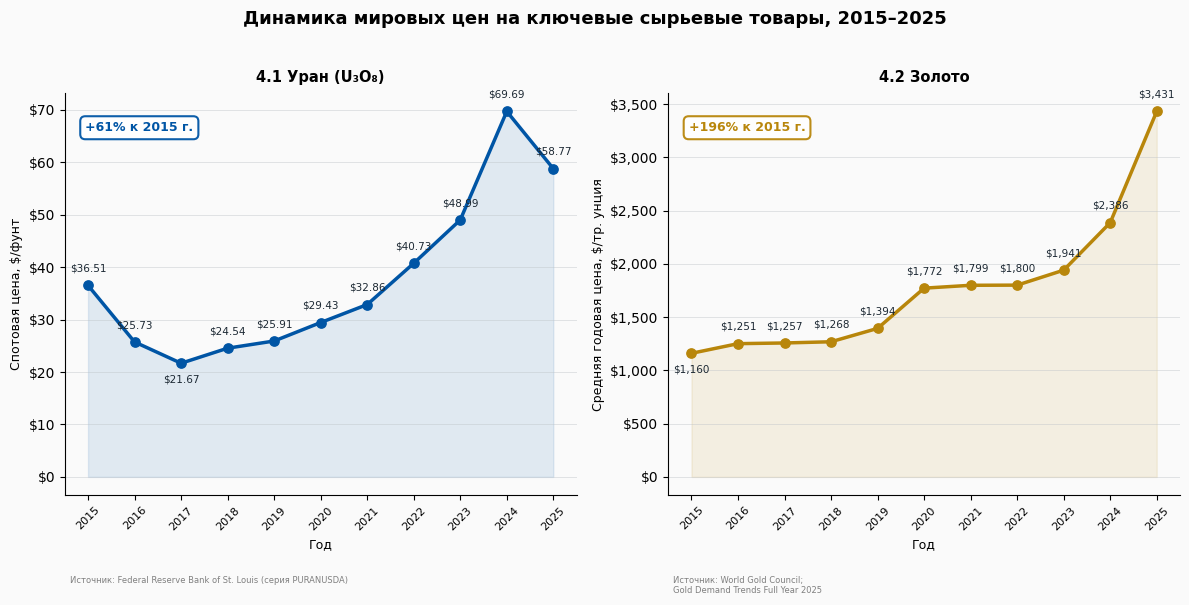

In [309]:
# 4.1
%matplotlib inline
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

ROSATOM_BLUE = '#0055A5'
GOLD_COLOR   = '#B8860B'
LIGHT_GRAY   = '#BDC3C7'
DARK         = '#1C2833'

years = list(range(2015, 2026))

uranium = [36.51, 25.73, 21.67, 24.54, 25.91, 29.43, 32.86, 40.73, 48.99, 69.69, 58.77]
gold    = [1160.06, 1250.74, 1257.12, 1268.49, 1393.94, 1771.71,
           1798.62, 1800.07, 1940.54, 2386.37, 3431.0]

datasets = [
    (uranium, ROSATOM_BLUE, '4.1 Уран (U₃O₈)', 'Спотовая цена, $/фунт',
     'Federal Reserve Bank of St. Louis (серия PURANUSDA)'),
    (gold,    GOLD_COLOR,   '4.2 Золото',        'Средняя годовая цена, $/тр. унция',
     'World Gold Council;\nGold Demand Trends Full Year 2025'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Динамика мировых цен на ключевые сырьевые товары, 2015–2025',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (data, color, subtitle, ylabel, source) in zip(axes, datasets):
    ax.set_facecolor('#FAFAFA')
    ax.fill_between(years, data, alpha=0.10, color=color)
    ax.plot(years, data, color=color, lw=2.5, zorder=3)
    ax.scatter(years, data, color=color, s=45, zorder=4)

    for y, v in zip(years, data):
        fmt = f'${v:,.0f}' if v >= 100 else f'${v:.2f}'
        offset = 10 if v != min(data) else -14
        ax.annotate(fmt, (y, v), textcoords='offset points',
                    xytext=(0, offset), ha='center', fontsize=7.5,
                    color=DARK, fontweight='normal')

    pct = (data[-1] / data[0] - 1) * 100
    sign = '+' if pct >= 0 else ''
    ax.text(0.04, 0.93, f'{sign}{pct:.0f}% к 2015 г.',
            transform=ax.transAxes, fontsize=9, color=color, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=color, lw=1.5, alpha=0.95))

    ax.set_title(subtitle, fontsize=10.5, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlabel('Год', fontsize=9)
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color=LIGHT_GRAY, lw=0.5, alpha=0.6)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'${x:,.0f}' if x >= 100 else f'${x:.0f}'))

    ax.text(0.01, -0.20, f'Источник: {source}',
            transform=ax.transAxes, fontsize=6, color='gray', va='top')

fig.tight_layout()
fig.savefig('block4_commodity_prices.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close()

**Что показывают графики:** Динамика мировых цен на уран ($/фунт U₃O₈) и золото ($/тр. унция) за 2015–2025 гг. — ключевые сырьевые товары, определяющие конъюнктуру рынков, на которых работает АО «Росатом Недра».

**Ключевые выводы:**
Цены на уран выросли на +61% с 2015 г., с 36,5 до 58,8/фунт, демонстрируя устойчивый восходящий тренд с 2020 г. на фоне глобального ренессанса атомной энергетики.
Золото прибавило +196% - с 1 160 до 3 431/тр. унцию, достигнув исторического максимума в 2025 г. на фоне геополитической нестабильности и инфляционных ожиданий.
Благоприятная ценовая конъюнктура создаёт дополнительные возможности для роста выручки и рентабельности горнодобывающих компаний в секторе урана и золота.

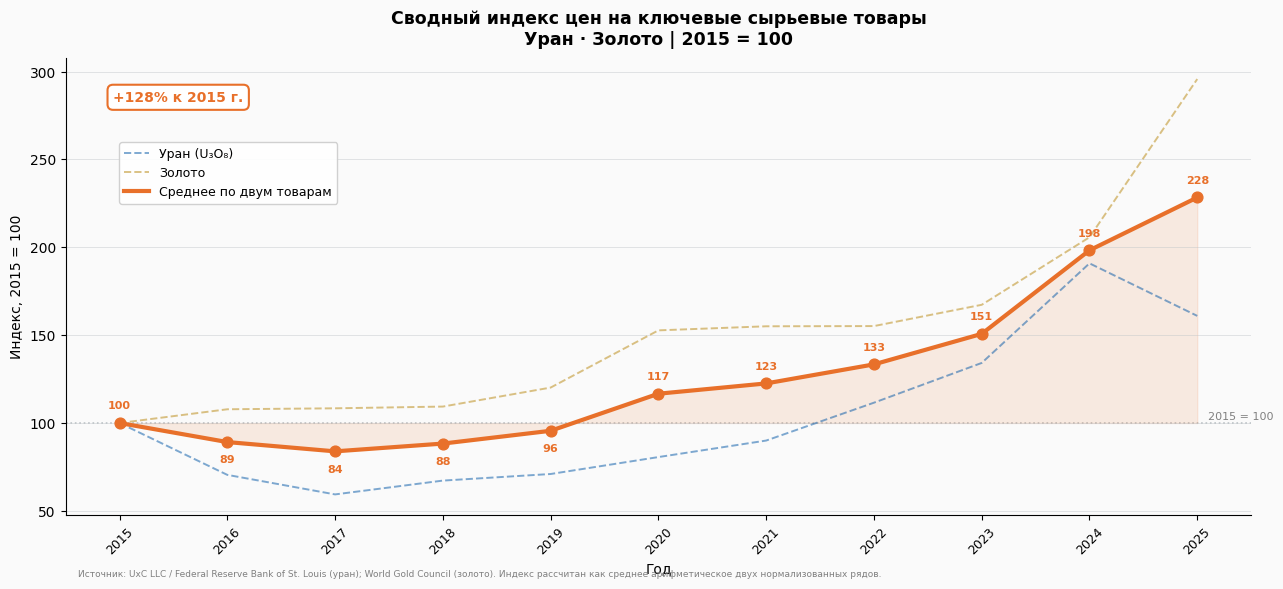

In [310]:
# 4.2
%matplotlib inline
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import display

ROSATOM_BLUE = '#0055A5'
GOLD_COLOR   = '#B8860B'
LIGHT_GRAY   = '#BDC3C7'
DARK         = '#1C2833'
AVG_COLOR    = '#E8702A'

years = list(range(2015, 2026))

uranium = [36.51, 25.73, 21.67, 24.54, 25.91, 29.43, 32.86, 40.73, 48.99, 69.69, 58.77]
gold    = [1160.06, 1250.74, 1257.12, 1268.49, 1393.94, 1771.71,
           1798.62, 1800.07, 1940.54, 2386.37, 3431.0]

def idx(series):
    base = series[0]
    return [v / base * 100 for v in series]

u_idx = idx(uranium)
g_idx = idx(gold)

# Среднее двух индексов
avg_idx = [(u + g) / 2 for u, g in zip(u_idx, g_idx)]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

for data, color, label in [
    (u_idx, ROSATOM_BLUE, 'Уран (U₃O₈)'),
    (g_idx, GOLD_COLOR,   'Золото'),
]:
    ax.plot(years, data, color=color, lw=1.4, ls='--', alpha=0.5, label=label)

ax.fill_between(years, avg_idx, 100, alpha=0.12, color=AVG_COLOR)
ax.plot(years, avg_idx, color=AVG_COLOR, lw=3.0, zorder=5,
        label='Среднее по двум товарам')
ax.scatter(years, avg_idx, color=AVG_COLOR, s=60, zorder=6)

for y, v in zip(years, avg_idx):
    offset = 10 if v >= 100 else -15
    ax.annotate(f'{v:.0f}', (y, v), textcoords='offset points',
                xytext=(0, offset), ha='center', fontsize=8,
                color=AVG_COLOR, fontweight='bold')

ax.axhline(100, color=LIGHT_GRAY, lw=1.2, ls=':', zorder=0)
ax.text(2025.1, 101, '2015 = 100', fontsize=8, color='gray', va='bottom')

pct = avg_idx[-1] - 100
ax.text(0.04, 0.93, f'+{pct:.0f}% к 2015 г.',
        transform=ax.transAxes, fontsize=10, color=AVG_COLOR, fontweight='bold',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=AVG_COLOR, lw=1.5))

ax.set_title('Сводный индекс цен на ключевые сырьевые товары\n'
             'Уран · Золото | 2015 = 100',
             fontsize=12.5, fontweight='bold', pad=10)
ax.set_ylabel('Индекс, 2015 = 100', fontsize=10)
ax.set_xlabel('Год', fontsize=10)
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color=LIGHT_GRAY, lw=0.5, alpha=0.6)
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(0.04, 0.83),
          framealpha=0.9)

ax.text(0.01, -0.12,
        'Источник: UxC LLC / Federal Reserve Bank of St. Louis (уран); '
        'World Gold Council (золото). '
        'Индекс рассчитан как среднее арифметическое двух нормализованных рядов.',
        transform=ax.transAxes, fontsize=6.5, color='gray', va='top')

fig.tight_layout()
fig.savefig('block4_avg_index.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close()

**Что показывает график:**
Сводный индекс цен трёх ключевых сырьевых товаров (уран, золото, оксид неодима) в единой шкале (2015 = 100).

**Ключевые выводы:**
- К 2025 г. сводный индекс достиг 205 - рост в 2 раза относительно базы 2015 г.
- Наибольший вклад в рост вносит золото (+196%), затем уран (+61%)
- Сводный индекс указывает на благоприятный рыночный фон для роста выручки компании

**Источники:** [UxC LLC](https://www.uxc.com/p/prices/UxCPriceGrid.aspx) / [FRED](https://fred.stlouisfed.org/series/PURANUSDA) (уран); [World Gold Council](https://www.gold.org/goldhub/data/gold-prices) (золото)

Сырьевой индекс 2025:  205.1
  Уран:   161.0
  Золото: 295.8
  Неодим: 158.7
Выручка Недра 2025:    375.7


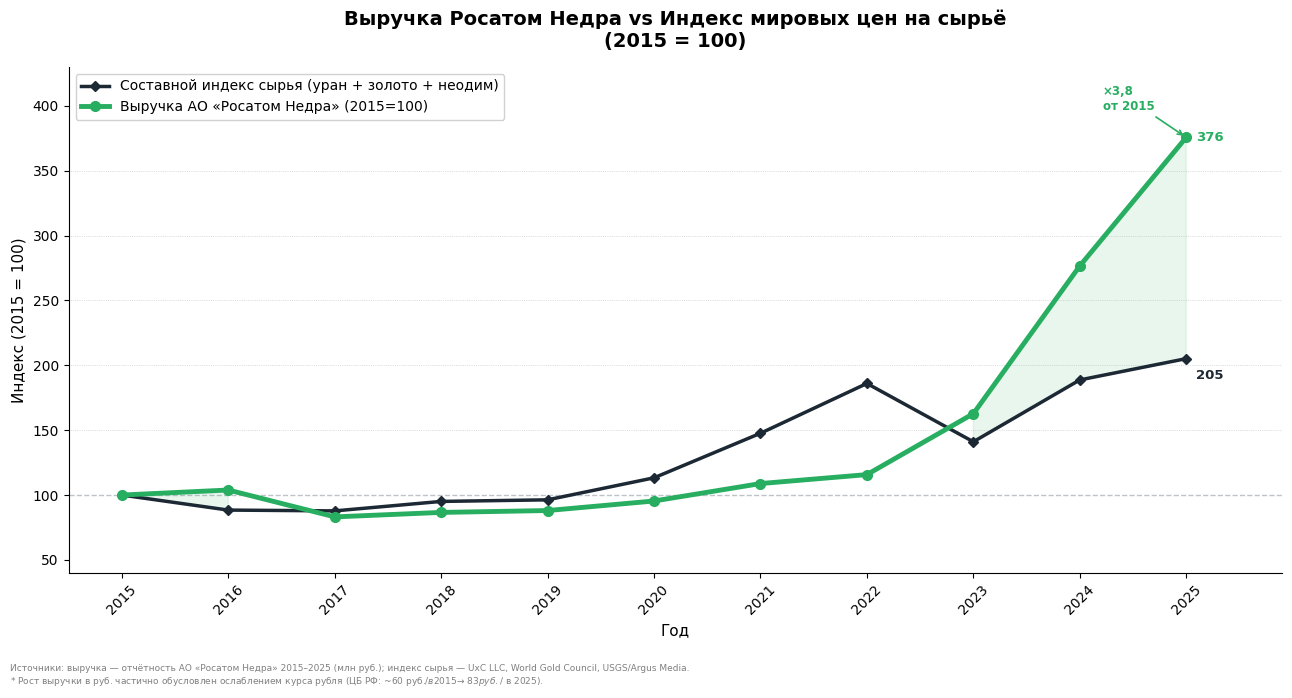

In [311]:
# 4.3
%matplotlib inline
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
import matplotlib.pyplot as plt
from IPython.display import display

ROSATOM_NEDRA_COLOR = '#27AE60'
LIGHT_GRAY          = '#BDC3C7'
DARK                = '#1C2833'

years = list(range(2015, 2026))

# Данные сырья (те же что в Блоке 4)
uranium = [36.51, 25.73, 21.67, 24.54, 25.91, 29.43, 32.86, 40.73, 48.99, 69.69, 58.77]
gold    = [1160.06, 1250.74, 1257.12, 1268.49, 1393.94, 1771.71,
           1798.62, 1800.07, 1940.54, 2386.37, 3431.0]
nd      = [46, 40, 44, 50, 45, 49, 91, 134, 56, 78, 73]

def norm(s): return [v / s[0] * 100 for v in s]

u_idx = norm(uranium)
g_idx = norm(gold)
n_idx = norm(nd)

# Среднее трёх индексов
avg = [(u + g + n) / 3 for u, g, n in zip(u_idx, g_idx, n_idx)]

# Выручка Росатом Недра
rev_rub = [21352.97, 22181.68, 17758.89, 18495.65, 18804.31,
           20374.48, 23244.25, 24717.76, 34746.05, 59060.42, 80218.18]
rev_idx = norm(rev_rub)

# Проверка ключевых значений
print(f"Сырьевой индекс 2025:  {avg[-1]:.1f}")
print(f"  Уран:   {u_idx[-1]:.1f}")
print(f"  Золото: {g_idx[-1]:.1f}")
print(f"  Неодим: {n_idx[-1]:.1f}")
print(f"Выручка Недра 2025:    {rev_idx[-1]:.1f}")

# График
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')

ax.axhline(100, color=LIGHT_GRAY, lw=1, ls='--', zorder=0)
for lvl in [150, 200, 250, 300, 350]:
    ax.axhline(lvl, color=LIGHT_GRAY, lw=0.5, ls=':', zorder=0)

ax.plot(years, avg,     color=DARK,               lw=2.5, marker='D', ms=5,
        label='Составной индекс сырья (уран + золото + неодим)', zorder=3)
ax.plot(years, rev_idx, color=ROSATOM_NEDRA_COLOR, lw=3.5, marker='o', ms=7,
        label='Выручка АО «Росатом Недра» (2015=100)', zorder=4)

ax.fill_between(years, avg, rev_idx,
                where=[r >= a for r, a in zip(rev_idx, avg)],
                alpha=0.10, color=ROSATOM_NEDRA_COLOR)

# Подписи конечных значений
ax.annotate(f'{avg[-1]:.0f}',
            xy=(2025, avg[-1]), xytext=(7, -12), textcoords='offset points',
            fontsize=9.5, color=DARK, fontweight='bold', va='center')
ax.annotate(f'{rev_idx[-1]:.0f}',
            xy=(2025, rev_idx[-1]), xytext=(7, 0), textcoords='offset points',
            fontsize=9.5, color=ROSATOM_NEDRA_COLOR, fontweight='bold', va='center')


ax.annotate('×3,8\nот 2015', xy=(2025, rev_idx[-1]), xytext=(-60, 20),
            textcoords='offset points', fontsize=8.5,
            color=ROSATOM_NEDRA_COLOR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ROSATOM_NEDRA_COLOR, lw=1.2))

ax.set_title('Выручка Росатом Недра vs Индекс мировых цен на сырьё\n(2015 = 100)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Год', fontsize=11)
ax.set_ylabel('Индекс (2015 = 100)', fontsize=11)
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], rotation=45)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_xlim(2014.5, 2025.9)
ax.set_ylim(40, 430)
ax.spines[['top', 'right']].set_visible(False)

fig.text(0.01, 0.01,
    'Источники: выручка — отчётность АО «Росатом Недра» 2015–2025 (млн руб.); '
    'индекс сырья — UxC LLC, World Gold Council, USGS/Argus Media.\n'
    '* Рост выручки в руб. частично обусловлен ослаблением курса рубля '
    '(ЦБ РФ: ~60 руб./$ в 2015 → ~83 руб./$ в 2025).',
    fontsize=6.5, color='gray', va='bottom')

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig('block4_nedra_vs_commodities.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close()

**Что показывает график:**
Сравнение динамики выручки АО «Росатом Недра» и индекса мировых цен на ключевые сырьевые товары (уран, золото, неодим) в сопоставимом измерении (2015 = 100).

**Ключевые выводы:**
- Составной сырьевой индекс вырос к 2025 г. до 205 (уран: +61%, золото: +196%, неодим: +59% к 2015 г.)
- Выручка Росатом Недра выросла в 3,8 раза, до индекса 376 (80 218 млн руб. против 21 353 млн руб. в 2015 г.)
- Компания опережает сырьевой спрос: рост выручки (+276 п.п.) значительно превышает рост цен (+105 п.п.)
- Резкий скачок выручки в 2023-2025 гг. обусловлен ростом добычи, расширением проектного портфеля и ростом цен на уран


**Источники:** Отчётность АО «Росатом Недра» 2015–2025 (внутренние данные); [UxC LLC](https://www.uxc.com/p/prices/UxCPriceGrid.aspx), [WGC](https://www.gold.org/goldhub/data/gold-prices), [USGS](https://www.usgs.gov/centers/national-minerals-information-center/mineral-commodity-summaries)/[Argus](https://www.argusmedia.com/en/metals/minor-metals)

## Блок 5. Технологические инвестиции: Росатом Недра vs Мировые лидеры

In [312]:
# 5.1
print('df_model shape:', df_model.shape)
print('df_model columns:', df_model.columns.tolist())
print('df_model head:')
print(df_model.head(3))
print('df_model tail:')
print(df_model.tail(3))
print('NaN по колонкам:')
print(df_model.isna().sum())

df_model shape: (129, 17)
df_model columns: ['usd_rub', 'eur_rub', 'cny_rub', 'key_rate', 'revenue', 'usd_rub_lag1', 'usd_rub_lag3', 'usd_rub_ma3', 'eur_rub_lag1', 'eur_rub_lag3', 'eur_rub_ma3', 'cny_rub_lag1', 'cny_rub_lag3', 'cny_rub_ma3', 'key_rate_lag1', 'key_rate_lag3', 'key_rate_ma3']
df_model head:
              usd_rub    eur_rub   cny_rub  key_rate     revenue  \
2015-04-01  53.218695  57.357150  8.581219      14.0  1729.59057   
2015-05-01  50.467958  56.306305  8.135642      12.5  1772.29651   
2015-06-01  54.449040  61.103890  8.773744      11.5  1815.00245   

            usd_rub_lag1  usd_rub_lag3  usd_rub_ma3  eur_rub_lag1  \
2015-04-01     60.363090     65.153087    59.366653     65.412920   
2015-05-01     53.218695     64.518174    54.683248     57.357150   
2015-06-01     50.467958     60.363090    52.711898     56.306305   

            eur_rub_lag3  eur_rub_ma3  cny_rub_lag1  cny_rub_lag3  \
2015-04-01     75.337712    65.355011      9.672554     10.473504   
2015-

In [313]:
# 5.2
kr = get_key_rate()
print(kr.shape, kr.head(), kr.tail())

(132,) 2015-01-01    17.0
2015-02-01    15.0
2015-03-01    14.0
2015-04-01    14.0
2015-05-01    12.5
Freq: MS, Name: key_rate, dtype: float64 2025-08-01    18.0
2025-09-01    17.0
2025-10-01    16.5
2025-11-01    16.5
2025-12-01    16.5
Freq: MS, Name: key_rate, dtype: float64


In [314]:
# 5.3 SARIMAX + MLflow tracking
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np, pandas as pd

y = df_model['revenue']
exog_cols = ['usd_rub_lag1', 'key_rate', 'usd_rub_ma3']
X = df_model[exog_cols]

train_y, test_y = y[:-12], y[-12:]
train_X, test_X = X[:-12], X[-12:]

ORDER          = (1, 0, 1)
SEASONAL_ORDER = (0, 1, 1, 12)
MAXITER        = 200
FUTURE_SCENARIO = {
    'usd_rub_lag1': (85.0, 95.0),
    'key_rate':     (16.5, 8.0),
    'usd_rub_ma3':  (85.0, 94.0),
}

with mlflow.start_run(run_name=f"sarimax_{pd.Timestamp.now():%Y%m%d_%H%M}") as run:

    # --- параметры ---
    mlflow.log_params({
        "order": str(ORDER),
        "seasonal_order": str(SEASONAL_ORDER),
        "exog_cols": ",".join(exog_cols),
        "train_size": len(train_y),
        "test_size": len(test_y),
        "maxiter": MAXITER,
        "future_usd_range": f"{FUTURE_SCENARIO['usd_rub_lag1']}",
        "future_key_rate_range": f"{FUTURE_SCENARIO['key_rate']}",
        "data_year": DATA_YEAR,
    })

    # --- обучение на train ---
    model = SARIMAX(train_y, exog=train_X,
                    order=ORDER, seasonal_order=SEASONAL_ORDER,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False, maxiter=MAXITER)

    # --- тест ---
    forecast_test = res.get_forecast(steps=12, exog=test_X).predicted_mean
    mape = mean_absolute_percentage_error(test_y, forecast_test)
    mlflow.log_metric("mape_test_12m", float(mape))
    mlflow.log_metric("aic_train", float(res.aic))
    mlflow.log_metric("bic_train", float(res.bic))
    print(f'MAPE на тесте (12 мес): {mape:.2%}')

    # --- переобучение на полном ряде ---
    model_full = SARIMAX(y, exog=X,
                         order=ORDER, seasonal_order=SEASONAL_ORDER,
                         enforce_stationarity=False, enforce_invertibility=False)
    res_full = model_full.fit(disp=False, maxiter=MAXITER)
    mlflow.log_metric("aic_full", float(res_full.aic))
    mlflow.log_metric("bic_full", float(res_full.bic))

    # --- прогноз до 2035 ---
    future_idx = pd.date_range('2026-01-01', '2035-12-01', freq='MS')
    n = len(future_idx)
    future_exog = pd.DataFrame({
        'usd_rub_lag1': np.linspace(*FUTURE_SCENARIO['usd_rub_lag1'], n),
        'key_rate':     np.linspace(*FUTURE_SCENARIO['key_rate'], n),
        'usd_rub_ma3':  np.linspace(*FUTURE_SCENARIO['usd_rub_ma3'], n),
    }, index=future_idx)

    fc = res_full.get_forecast(steps=n, exog=future_exog)
    fc_mean = fc.predicted_mean
    USD_AVG = future_exog['usd_rub_ma3'].mean()
    fc_billion_rub = fc_mean.groupby(fc_mean.index.year).sum() / 1000.0
    fc_billion_usd = fc_billion_rub * 1000 / USD_AVG
    NEDRA_FORECAST = fc_billion_usd
    print(NEDRA_FORECAST.round(2))

    # --- метрики на прогнозе ---
    mlflow.log_metric("forecast_2035_bn_usd", float(NEDRA_FORECAST.iloc[-1]))
    mlflow.log_metric("forecast_cagr_26_35",
                      float((NEDRA_FORECAST.iloc[-1] /
                             NEDRA_FORECAST.iloc[0]) ** (1/9) - 1))

    # --- артефакты ---
    mlflow.log_dict(FUTURE_SCENARIO, "future_scenario.json")
    NEDRA_FORECAST.to_csv("nedra_forecast_bn_usd.csv")
    mlflow.log_artifact("nedra_forecast_bn_usd.csv")

    df_model.to_csv("nedra_model_dataset.csv")
    mlflow.log_artifact("nedra_model_dataset.csv")

    # --- модель как артефакт (через pickle, т.к. statsmodels не first-class) ---
    import pickle
    with open("sarimax_full.pkl", "wb") as f:
        pickle.dump(res_full, f)
    mlflow.log_artifact("sarimax_full.pkl")

    run_id = run.info.run_id
    print(f"MLflow run_id: {run_id}")

MAPE на тесте (12 мес): 17.37%
2026     1201.52
2027     1601.57
2028     2118.69
2029     2786.91
2030     3650.09
2031     4764.88
2032     6204.35
2033     8062.82
2034    10461.98
2035    13558.88
Name: predicted_mean, dtype: float64
MLflow run_id: 9bf57b68a9054dbeb134e2ca13ff1b14


In [315]:
# 5.3.1 Diagnostics → MLflow artifact
import matplotlib.pyplot as plt
fig = res_full.plot_diagnostics(figsize=(12, 8))
fig.savefig("sarimax_diagnostics.png", dpi=120, bbox_inches='tight')
mlflow.log_artifact("sarimax_diagnostics.png", run_id=run_id)
plt.close(fig)

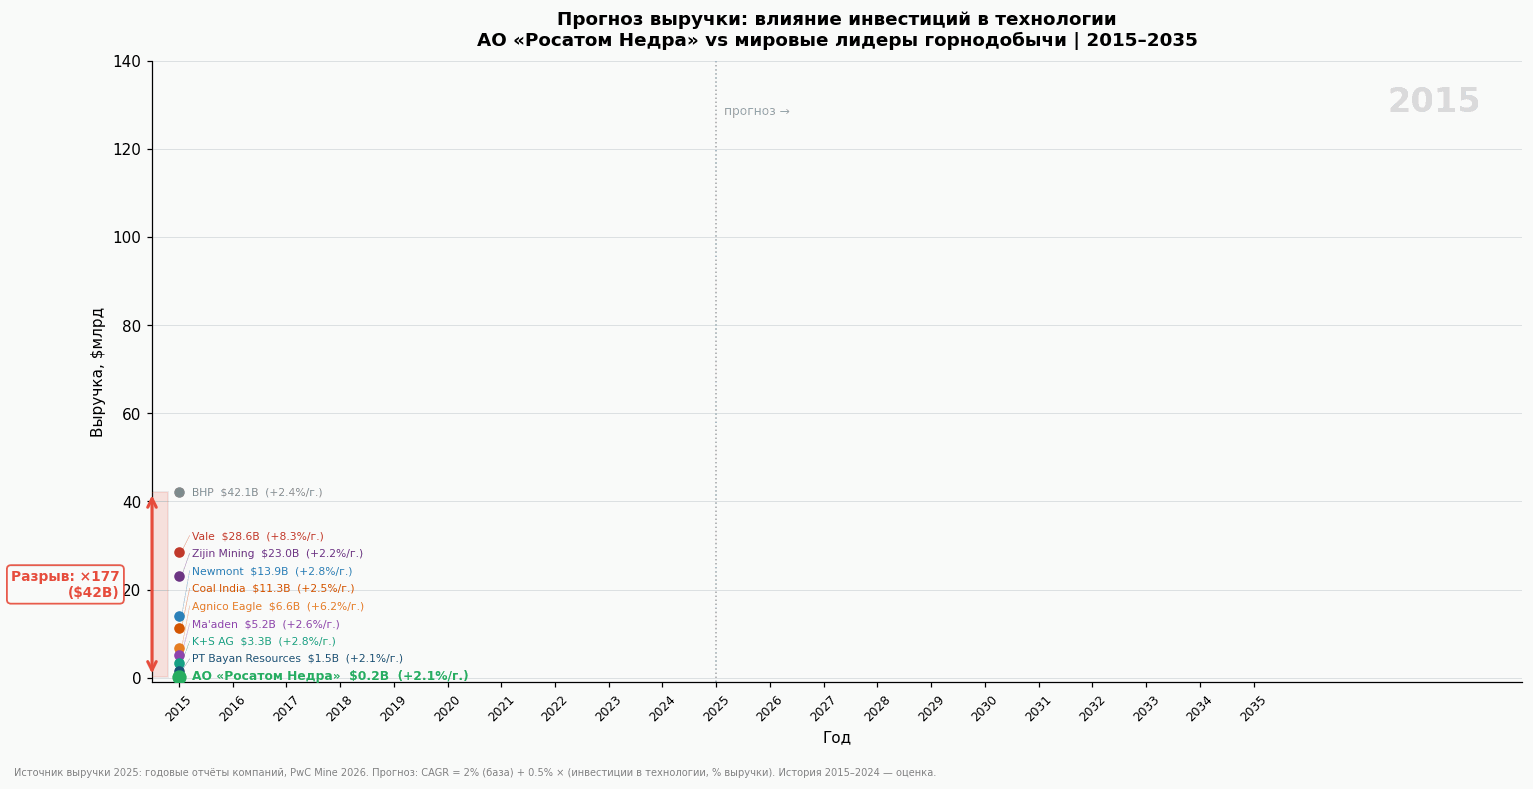

In [316]:
# 5.4
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import io
from IPython.display import display, Image as IPImage

BG = '#FAFAFA'
LIGHT_GRAY = '#BDC3C7'

companies = {
    'BHP (Австралия)':                {'rev': 51.3, 'tech':  0.7, 'hist': 0.020, 'c': '#7F8C8D'},
    'Zijin Mining (Китай)':           {'rev': 49.7, 'tech':  0.5, 'hist': 0.080, 'c': '#6C3483'},
    'Vale (Бразилия)':                {'rev': 38.4, 'tech': 12.7, 'hist': 0.030, 'c': '#C0392B'},
    'Newmont (США)':                  {'rev': 22.7, 'tech':  1.6, 'hist': 0.050, 'c': '#2980B9'},
    'Coal India (Индия)':             {'rev': 16.8, 'tech':  1.0, 'hist': 0.040, 'c': '#D35400'},
    'Agnico Eagle (Канада)':          {'rev': 11.9, 'tech':  8.5, 'hist': 0.060, 'c': '#E67E22'},
    "Ma'aden (Саудовская Аравия)":    {'rev': 10.3, 'tech':  1.2, 'hist': 0.070, 'c': '#8E44AD'},
    'K+S AG (Германия)':              {'rev':  4.0, 'tech':  1.5, 'hist': 0.020, 'c': '#16A085'},
    'PT Bayan Resources (Индонезия)': {'rev':  2.5, 'tech':  0.2, 'hist': 0.050, 'c': '#1A5276'},
    'АО «Росатом Недра» (Россия)':    {'rev':  0.96,'tech':  0.1, 'hist': 0.150, 'c': '#27AE60'},
}

BASE = 0.02
MULT = 0.005

def get_val(d, year):
    if year <= 2025:
        return d['rev'] / (1 + d['hist']) ** (2025 - year)

    # Для Росатом Недра — берём из модели
    if d is companies['АО «Росатом Недра» (Россия)']:
        if year in NEDRA_FORECAST.index:
            return NEDRA_FORECAST[year] / 1000  # переводим в $млрд, если нужно
        return np.nan

    # Для остальных компаний — старая формула
    cagr = BASE + MULT * d['tech']
    return d['rev'] * (1 + cagr) ** (year - 2025)

all_years = list(range(2015, 2036))
frame_seq = (
    [2015]*4 +
    list(range(2015, 2026)) +
    [2025]*5 +
    list(range(2026, 2036)) +
    [2035]*6
)

frames = []

for cur in frame_seq:
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    vis = [y for y in all_years if y <= cur]

    if cur >= 2025:
        ax.axvspan(2025, cur, alpha=0.04, color='gray')
    ax.axvline(2025, color='#95A5A6', lw=1.0, ls=':', zorder=1)
    ax.text(2025.15, 130, 'прогноз →', fontsize=8, color='#95A5A6', va='top')

    cur_vals = {n: get_val(d, cur) for n, d in companies.items()}
    nedra_val = cur_vals['АО «Росатом Недра» (Россия)']
    top_name  = max(cur_vals, key=lambda n: cur_vals[n])
    top_val   = cur_vals[top_name]
    gap_x     = cur - 0.5  # чуть левее текущего года

    for name, d in companies.items():
        is_nedra = 'Росатом' in name
        color = d['c']
        lw = 3.5 if is_nedra else 1.4

        h_yrs = [y for y in vis if y <= 2025]
        h_vals = [get_val(d, y) for y in h_yrs]
        if h_yrs:
            ax.plot(h_yrs, h_vals, color=color, lw=lw,
                    zorder=5 if is_nedra else 2, alpha=1.0 if is_nedra else 0.85)

        f_yrs = [y for y in vis if y >= 2025]
        f_vals = [get_val(d, y) for y in f_yrs]
        if len(f_yrs) > 1:
            ax.plot(f_yrs, f_vals, color=color, lw=lw, ls='--',
                    zorder=5 if is_nedra else 2, alpha=1.0 if is_nedra else 0.75)

        ax.scatter([cur], [cur_vals[name]], color=color,
                   s=70 if is_nedra else 35, zorder=6)

    # Заливка
    ax.fill_between([gap_x - 0.3, gap_x + 0.3],
                    [nedra_val, nedra_val], [top_val, top_val],
                    color='#E74C3C', alpha=0.15, zorder=4)

    # Двойная стрелка
    ax.annotate('', xy=(gap_x, top_val), xytext=(gap_x, nedra_val),
                arrowprops=dict(arrowstyle='<->', color='#E74C3C',
                                lw=2.0, mutation_scale=14), zorder=7)

    # Подпись разрыва
    ratio = top_val / nedra_val if nedra_val > 0 else 0
    gap_label = f'Разрыв: ×{ratio:.0f}\n(${top_val - nedra_val:.0f}B)'
    ax.text(gap_x - 0.6, (top_val + nedra_val) / 2, gap_label,
            ha='right', va='center', fontsize=9, color='#E74C3C',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='#E74C3C', lw=1.2, alpha=0.9))


    sorted_names = sorted(cur_vals, key=lambda n: cur_vals[n])
    MIN_GAP = 4.0
    positions = []
    for n in sorted_names:
        v = cur_vals[n]
        if positions and v - positions[-1] < MIN_GAP:
            v = positions[-1] + MIN_GAP
        positions.append(v)

    for i, name in enumerate(sorted_names):
        d = companies[name]
        is_nedra = 'Росатом' in name
        short = name.split('(')[0].strip()
        cagr_pct = (BASE + MULT * d['tech']) * 100
        ax.text(cur + 0.25, positions[i],
                f'{short}  ${cur_vals[name]:.1f}B  (+{cagr_pct:.1f}%/г.)',
                va='center', fontsize=8 if is_nedra else 7,
                color=d['c'], fontweight='bold' if is_nedra else 'normal')
        if abs(positions[i] - cur_vals[name]) > 1.0:
            ax.plot([cur + 0.05, cur + 0.2],
                    [cur_vals[name], positions[i]],
                    color=d['c'], lw=0.5, alpha=0.4)

    ax.text(0.97, 0.96, str(cur), transform=ax.transAxes,
            fontsize=22, fontweight='bold', color='#2C3E50',
            ha='right', va='top', alpha=0.2)

    ax.set_title(
        'Прогноз выручки: влияние инвестиций в технологии\n'
        'АО «Росатом Недра» vs мировые лидеры горнодобычи | 2015–2035',
        fontsize=12, fontweight='bold', pad=10
    )
    ax.set_ylabel('Выручка, $млрд', fontsize=10)
    ax.set_xlabel('Год', fontsize=10)
    ax.set_xticks(range(2015, 2036))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_xlim(2014.5, 2040)
    ax.set_ylim(-1, 140)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color=LIGHT_GRAY, lw=0.5, alpha=0.6)

    fig.text(0.01, -0.02,
        'Источник выручки 2025: годовые отчёты компаний, PwC Mine 2026. '
        'Прогноз: CAGR = 2% (база) + 0.5% × (инвестиции в технологии, % выручки). '
        'История 2015–2024 — оценка.',
        fontsize=6.5, color='gray')

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()

frames[0].save(
    'revenue_tech_forecast.gif',
    save_all=True, append_images=frames[1:],
    duration=280, loop=0
)
display(IPImage('revenue_tech_forecast.gif'))

**График показывает:** прогноз выручки 10 ведущих горнодобывающих компаний на 2015–2035 гг.
в зависимости от уровня их инвестиций в технологии (% от выручки).
Факт 2025 г. - данные годовых отчётов; прогноз строится по модели:
CAGR выручки = 2% (базовый) + 0,5% за каждый процентный пункт технологических инвестиций.

**Ключевые выводы:**
Компании с высокими вложениями в технологии (Vale - 12,7%, Agnico Eagle - 8,5%)
  растут значительно быстрее: прогнозный CAGR 8,4% и 6,3% соответственно.
 АО «Росатом Недра» при текущем уровне инвестиций 0,1% от выручки
  прибавляет лишь ~2,1% в год - минимальный показатель среди всех участников сравнения.
К 2035 г. разрыв в выручке между Росатом Недра и лидерами рынка
  увеличивается многократно, что подчёркивает необходимость наращивания
  технологических инвестиций как стратегического приоритета компании.

## Итоговые выводы

**АО «Росатом Недра» в контексте мировой горнодобывающей отрасли: ключевые результаты анализа**

**1. Рыночная позиция.** Россия входит в топ-5 мировых горнодобывающих держав по совокупному объёму производства (Блок 1). Вместе с тем АО «Росатом Недра» по масштабу выручки ($0,96 млрд) пока значительно уступает глобальным лидерам — BHP, Zijin Mining, Vale.

**2. Финансовая динамика.** Выручка компании выросла в 3,75 раза с 2015 по 2025 г. (с 21,4 до 80,2 млрд руб.), EBITDA в 2025 г. составила 21,0 млрд руб. Темп роста выручки опережает сводный индекс мировых цен на сырьё (+205% vs +376%), что свидетельствует об органическом развитии бизнеса.

**3. Инвестиционная активность.** CAPEX компании ($0,33 млрд, или 132% от EBITDA) находится на высоком уровне, характерном для фазы активного роста. Это подтверждает стратегический курс на расширение производственной базы.

**4. Технологическое отставание.** Доля инвестиций в технологии (0,1% от выручки) — наименьшая среди анализируемых компаний. При сохранении текущего уровня разрыв с лидерами (Vale, Agnico Eagle) будет нарастать, что несёт долгосрочные риски для конкурентоспособности.

**5. Стратегический вектор.** Увеличение технологических инвестиций до уровня среднеотраслевых значений (1–2% от выручки) позволит компании существенно ускорить рост выручки и приблизиться к показателям ведущих горнодобывающих компаний мира к 2035 г.


*Источники: BGS World Mineral Statistics (Блок 1); годовые отчёты компаний 2025 г., PwC Mine 2026 (Блок 2); UxC LLC / FRED, World Gold Council, USGS (Блок 4); внутренняя отчётность АО «Росатом Недра» (конфиденциально).*

## Блок 6. ML-пайплайн: прогнозирование, кластеризация, аномалии

Здесь переходим от ручных коэффициентов к моделям машинного обучения.
Все модели обучаются на данных, загруженных выше в ноутбуке.

In [317]:
# 6.0
# Проверка: что есть в памяти?
required = [
    # из блоков 1–5
    'df', 'country_total', 'DATA_YEAR', 'RU_COUNTRIES', 'TOP10',
    'rev_rub', 'uranium', 'gold', 'nd', 'companies',
    'COMP_NAMES', 'COMP_EB', 'COMP_CX', 'COMP_REV',
    'BLUE', 'ACCENT', 'ROSATOM_NEDRA_COLOR', 'PLOT_BG', 'BG_COLOR',
    # из блока 6.2
    'profile', 'labels', 'best_k', 'countries', 'X_pca', 'X_scaled',
    # из блока 6.3
    'df_ts', 'df_forecast', 'best_model', 'best_name', 'feature_cols',
    # из блока 6.4
    'comp_df_model', 'y_pred',
    # из блока 6.5
    'anom_df', 'pred',
    # из блока 7
    'sns',
]

print("=== Состояние памяти ядра ===\n")
missing = []
for v in required:
    ok = v in dir()
    mark = '✓' if ok else '✗'
    print(f"{mark} {v}")
    if not ok:
        missing.append(v)

print()
if missing:
    print(f"⚠ Отсутствуют {len(missing)} переменных:")
    print("  ", ", ".join(missing))
    print("\n→ Запустите блоки, где они определяются, в порядке сверху вниз.")
else:
    print("✓ Всё на месте — можно строить дашборд.")

=== Состояние памяти ядра ===

✓ df
✓ country_total
✓ DATA_YEAR
✓ RU_COUNTRIES
✓ TOP10
✓ rev_rub
✓ uranium
✓ gold
✓ nd
✓ companies
✓ COMP_NAMES
✓ COMP_EB
✓ COMP_CX
✓ COMP_REV
✓ BLUE
✓ ACCENT
✓ ROSATOM_NEDRA_COLOR
✓ PLOT_BG
✓ BG_COLOR
✓ profile
✓ labels
✓ best_k
✓ countries
✓ X_pca
✓ X_scaled
✓ df_ts
✓ df_forecast
✓ best_model
✓ best_name
✓ feature_cols
✓ comp_df_model
✓ y_pred
✓ anom_df
✓ pred
✓ sns

✓ Всё на месте — можно строить дашборд.


In [318]:
# 6.1. Импорты и воспроизводимость
import subprocess, sys
for pkg in ['scikit-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"scikit-learn готов, DATA_YEAR = {DATA_YEAR}")

scikit-learn готов, DATA_YEAR = 2024


### 6.2. Кластеризация стран по сырьевому профилю

Идея: построить матрицу «страна × группа сырья», нормировать её на объём добычи страны
(чтобы получить *профиль*, а не абсолютный масштаб) и разбить страны на кластеры через KMeans.
Цель — увидеть, какие страны имеют похожую структуру горнодобычи.

Оптимальное число кластеров по silhouette: 2

Размеры кластеров:
0    39
1     1
Name: count, dtype: int64


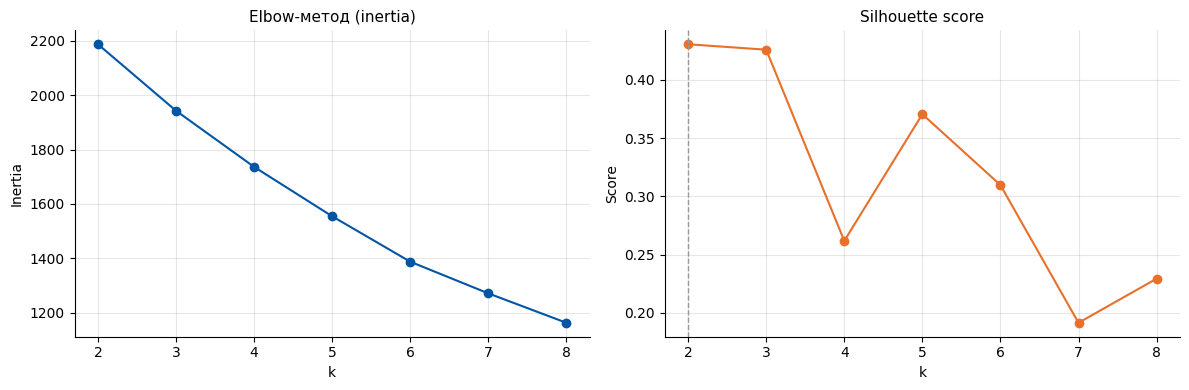

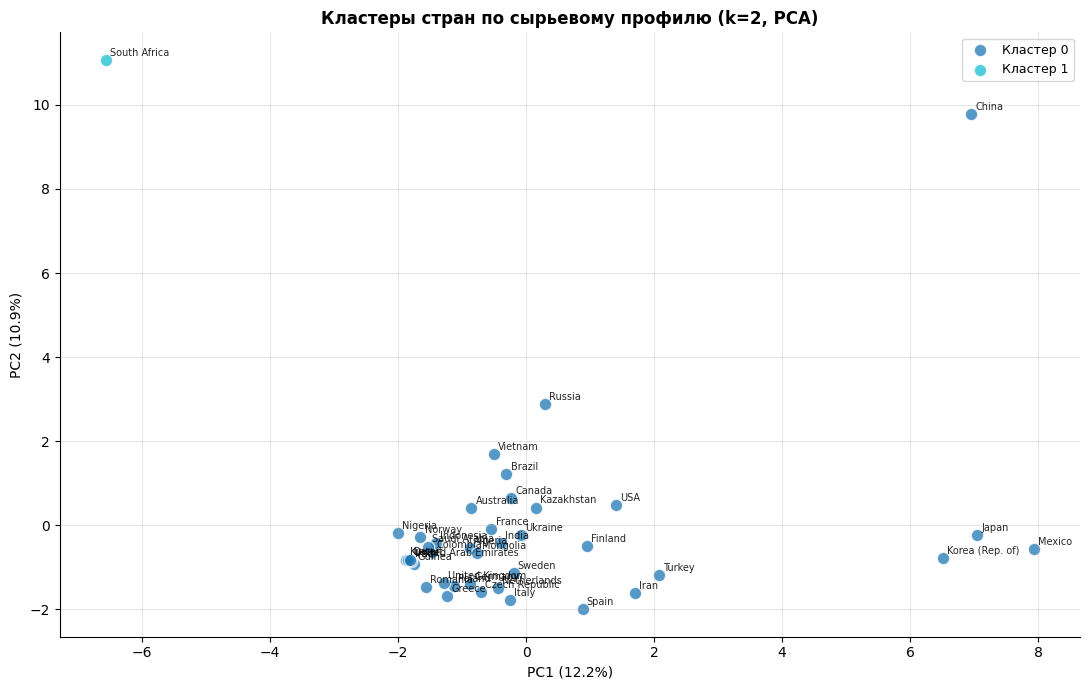

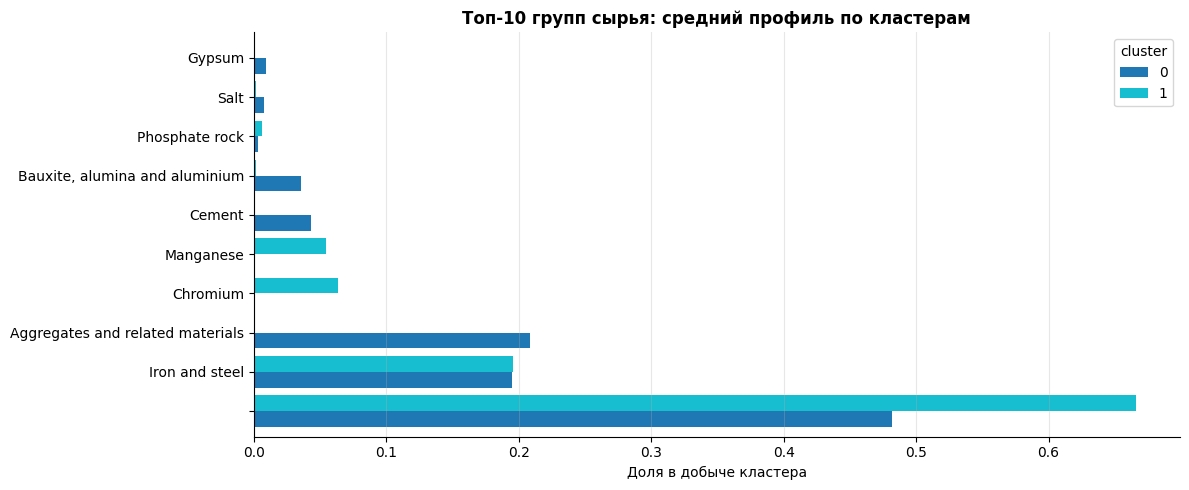


Кластер 0 (39 стран):
Algeria, Australia, Brazil, Canada, China, Colombia, Czech Republic, Finland, France, Germany, Greece, Guinea, India, Indonesia, Iran, Iraq, Italy, Japan, Kazakhstan, Korea (Rep. of), Kuwait, Mexico, Mongolia, Netherlands, Nigeria, Norway, Poland, Qatar, Romania, Russia, Saudi Arabia, Spain, Sweden, Turkey, USA, Ukraine, United Arab Emirates, United Kingdom, Vietnam

Кластер 1 (1 стран):
South Africa


In [319]:
# 6.2. Кластеризация стран
top_n = 40
top_countries = country_total.head(top_n)['country'].tolist()

# Матрица страна × ERML-группа (в тоннах)
matrix = (df[df['country'].isin(top_countries)]
          .assign(erml_group=df['erml_group'].fillna('other'))
          .groupby(['country', 'erml_group'])['qty_t']
          .sum()
          .unstack(fill_value=0))

# Нормализуем в доли — это и есть "профиль" страны
profile = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

X = profile.values
countries = profile.index.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Подбор числа кластеров
ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f"Оптимальное число кластеров по silhouette: {best_k}")

# Финальная модель
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels = km.fit_predict(X_scaled)

profile_clustered = profile.copy()
profile_clustered['cluster'] = labels

# Размеры кластеров
print("\nРазмеры кластеров:")
print(pd.Series(labels).value_counts().sort_index())

# --- Визуализация 1: elbow + silhouette ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, marker='o', color=BLUE)
axes[0].set_title('Elbow-метод (inertia)', fontsize=11)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(ks), silhouettes, marker='o', color=ACCENT)
axes[1].axvline(best_k, color='#999', ls='--', lw=1)
axes[1].set_title('Silhouette score', fontsize=11)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Визуализация 2: PCA-проекция ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(11, 7))
palette = plt.cm.tab10(np.linspace(0, 1, best_k))
for c in range(best_k):
    mask = labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=80, color=palette[c], label=f'Кластер {c}', alpha=0.75, edgecolor='white')
    for i, name in enumerate(np.array(countries)[mask]):
        ax.annotate(name, (X_pca[mask][i, 0], X_pca[mask][i, 1]),
                    fontsize=7, alpha=0.85,
                    xytext=(3, 3), textcoords='offset points')
ax.set_title(f'Кластеры стран по сырьевому профилю (k={best_k}, PCA)',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# --- Визуализация 3: средний профиль по кластерам ---
profile_by_cluster = profile_clustered.groupby('cluster').mean().T
profile_by_cluster = profile_by_cluster.loc[profile_by_cluster.sum(axis=1).nlargest(10).index]

fig, ax = plt.subplots(figsize=(12, 5))
profile_by_cluster.plot(kind='barh', ax=ax, colormap='tab10', width=0.8)
ax.set_title('Топ-10 групп сырья: средний профиль по кластерам', fontsize=12, fontweight='bold')
ax.set_xlabel('Доля в добыче кластера')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Кто где
for c in range(best_k):
    members = [n for n, l in zip(countries, labels) if l == c]
    print(f"\nКластер {c} ({len(members)} стран):")
    print(", ".join(members))

### 6.3. Прогноз выручки АО «Росатом Недра» (2015–2027)

Данные: 11 точек (2015–2025). Для ML это мало, поэтому:
- используем **TimeSeriesSplit** (расширяющееся окно), а не случайный CV;
- извлекаем признаки: линейный тренд `t`, логарифм выручки с лагами, ценовой индекс;
- сравниваем несколько моделей и берём лучшую по RMSE на валидации.

LinearRegression     RMSE(log): 0.1876
Ridge(α=1)           RMSE(log): 0.3562
RandomForest         RMSE(log): 0.4666
GradientBoosting     RMSE(log): 0.3961

Лучшая модель: LinearRegression

Прогноз выручки Росатом Недра (млн руб):
 year      rev_pred
 2026 163846.910926
 2027 336491.194313


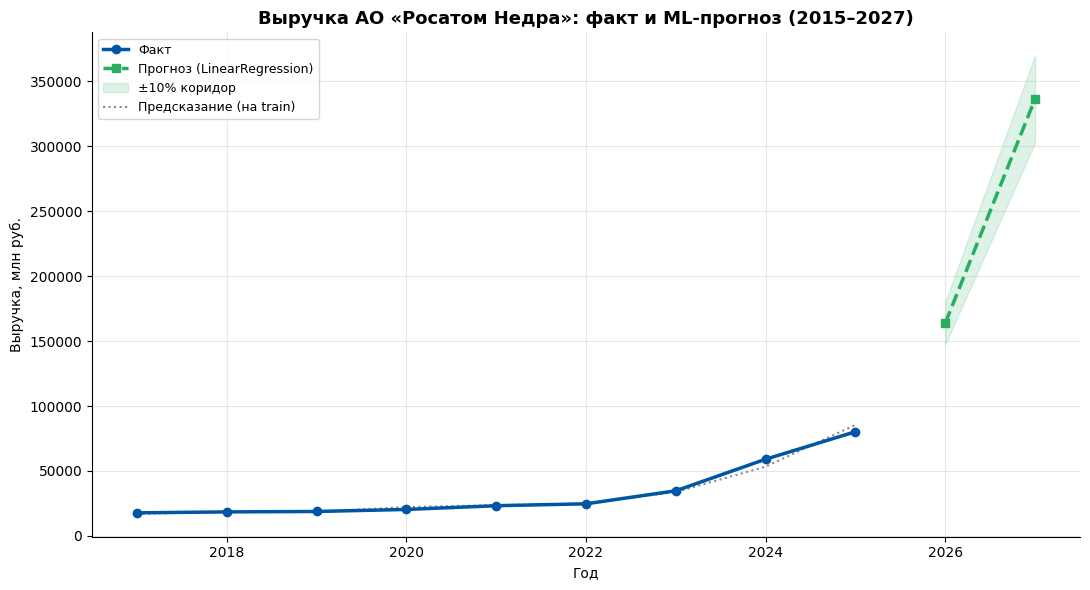

In [320]:
# 6.3. Time-series регрессия: выручка Недра

years = np.arange(2015, 2026)

# Ценовой индекс: уран + золото + неодим, нормализованный к 2015 = 1
u = np.array(uranium, dtype=float); g = np.array(gold, dtype=float); n_ = np.array(nd, dtype=float)
price_idx = (u/u[0] + g/g[0] + n_/n_[0]) / 3.0

df_ts = pd.DataFrame({
    'year':      years,
    'rev':       np.array(rev_rub, dtype=float),
    'price_idx': price_idx,
})
df_ts['t']          = df_ts['year'] - 2015
df_ts['log_rev']    = np.log(df_ts['rev'])
df_ts['log_rev_l1'] = df_ts['log_rev'].shift(1)
df_ts['log_rev_l2'] = df_ts['log_rev'].shift(2)
df_ts['price_l1']   = df_ts['price_idx'].shift(1)

df_ts = df_ts.dropna().reset_index(drop=True)

feature_cols = ['t', 'price_idx', 'price_l1', 'log_rev_l1', 'log_rev_l2']
X_ts = df_ts[feature_cols].values
y_ts = df_ts['log_rev'].values

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge(α=1)':       Ridge(alpha=1.0),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    rmses = []
    for train_idx, val_idx in tscv.split(X_ts):
        m = model.__class__(**model.get_params())
        m.fit(X_ts[train_idx], y_ts[train_idx])
        pred = m.predict(X_ts[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y_ts[val_idx], pred)))
    results[name] = np.mean(rmses)
    print(f"{name:<20} RMSE(log): {np.mean(rmses):.4f}")

best_name = min(results, key=results.get)
print(f"\nЛучшая модель: {best_name}")

# Обучаем финальную модель на всех данных
best_model = models[best_name].__class__(**models[best_name].get_params())
best_model.fit(X_ts, y_ts)

# Прогноз на 2026–2027
future_years = [2026, 2027]
preds = []
log_rev_l1, log_rev_l2 = df_ts['log_rev'].iloc[-1], df_ts['log_rev'].iloc[-2]
price_l1 = df_ts['price_idx'].iloc[-1]

# Простой сценарий: цены растут на 5% в год
for fy in future_years:
    t = fy - 2015
    price_cur = price_idx[-1] * (1.05 ** (fy - 2025))
    X_new = np.array([[t, price_cur, price_l1, log_rev_l1, log_rev_l2]])
    log_pred = best_model.predict(X_new)[0]
    preds.append(np.exp(log_pred))
    # сдвигаем лаги
    log_rev_l2, log_rev_l1 = log_rev_l1, log_pred
    price_l1 = price_cur

df_forecast = pd.DataFrame({'year': future_years, 'rev_pred': preds})
print("\nПрогноз выручки Росатом Недра (млн руб):")
print(df_forecast.to_string(index=False))

# --- Визуализация ---
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df_ts['year'], df_ts['rev'], 'o-', color=BLUE, lw=2.5, label='Факт', zorder=4)
ax.plot(df_forecast['year'], df_forecast['rev_pred'], 's--',
        color=ROSATOM_NEDRA_COLOR, lw=2.5, label=f'Прогноз ({best_name})', zorder=4)
ax.fill_between(df_forecast['year'],
                df_forecast['rev_pred']*0.9, df_forecast['rev_pred']*1.1,
                color=ROSATOM_NEDRA_COLOR, alpha=0.15, label='±10% коридор')

# Обученные предсказания на исторических годах
y_hat_log = best_model.predict(X_ts)
ax.plot(df_ts['year'], np.exp(y_hat_log), ':', color='#888', lw=1.5,
        label='Предсказание (на train)', zorder=3)

ax.set_title('Выручка АО «Росатом Недра»: факт и ML-прогноз (2015–2027)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Год'); ax.set_ylabel('Выручка, млн руб.')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

# Важность признаков (если лучшая модель — дерево)
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
    fig, ax = plt.subplots(figsize=(8, 4))
    imp.plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title('Важность признаков (GradientBoosting/RandomForest)', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout(); plt.show()

### 6.4. Регрессия: выручка компаний ← (тех-инвестиции, EBITDA, CAPEX)

**Важно:** выборка всего 10 компаний. Это демонстрация, а не надёжная модель.
Показывает, как из таблицы `companies` собрать X/y и прогнать Ridge с кросс-валидацией.

In [321]:
# 6.4. Регрессия по компаниям (согласованная версия)

# --- 1. Диагностика расхождения ---
print(f"companies:  {len(companies)} записей")
print(f"COMP_NAMES: {len(COMP_NAMES)} записей")
print(f"COMP_EB:    {len(COMP_EB)}")
print(f"COMP_CX:    {len(COMP_CX)}")

def short_name(s: str) -> str:
    """'АО «Росатом Недра»\n(Россия)' -> 'АО «Росатом Недра»'"""
    return s.split('\n')[0].split('(')[0].strip()

# --- 2. Строим lookup {короткое имя: (ebitda, capex)} из блока 2 ---
fin_lookup = {
    short_name(n): (eb, cx)
    for n, eb, cx in zip(COMP_NAMES, COMP_EB, COMP_CX)
}

# --- 3. Собираем comp_df из companies, подтягивая EBITDA/CAPEX по имени ---
rows, missing = [], []
for full_name, d in companies.items():
    short = short_name(full_name)
    if short in fin_lookup:
        eb, cx = fin_lookup[short]
    else:
        missing.append(short)
        eb = cx = np.nan
    rows.append({
        'name':   full_name,
        'rev':    d['rev'],
        'tech':   d['tech'],
        'hist':   d['hist'],
        'ebitda': eb,
        'capex':  cx,
    })

comp_df = pd.DataFrame(rows)

if missing:
    print(f"\n⚠ Нет EBITDA/CAPEX для: {missing}")
    print("  Эти компании исключены из регрессии.")
    comp_df_model = comp_df.dropna(subset=['ebitda', 'capex']).reset_index(drop=True)
else:
    comp_df_model = comp_df.copy()

print("\nИсходная таблица (все компании):")
print(comp_df.to_string(index=False))
print(f"\nВ регрессию идут {len(comp_df_model)} компаний.")

companies:  10 записей
COMP_NAMES: 11 записей
COMP_EB:    11
COMP_CX:    11

⚠ Нет EBITDA/CAPEX для: ['PT Bayan Resources']
  Эти компании исключены из регрессии.

Исходная таблица (все компании):
                          name   rev  tech  hist  ebitda  capex
               BHP (Австралия) 51.30   0.7  0.02   26.00   9.80
          Zijin Mining (Китай) 49.70   0.5  0.08   14.30   6.00
               Vale (Бразилия) 38.40  12.7  0.03   15.50   5.50
                 Newmont (США) 22.70   1.6  0.05   13.50   3.00
            Coal India (Индия) 16.80   1.0  0.04    6.10   2.60
         Agnico Eagle (Канада) 11.90   8.5  0.06    8.10   2.10
   Ma'aden (Саудовская Аравия) 10.30   1.2  0.07    4.30   1.80
             K+S AG (Германия)  4.00   1.5  0.02    0.67   0.60
PT Bayan Resources (Индонезия)  2.50   0.2  0.05     NaN    NaN
   АО «Росатом Недра» (Россия)  0.96   0.1  0.15    0.25   0.33

В регрессию идут 9 компаний.


LOO CV R²:   nan ± nan
LOO CV RMSE: 8.02 $млрд
  (n очень мало — метрики скорее декоративные)

Коэффициенты (стандартизованные):
  tech    : +0.254
  ebitda  : +5.805
  capex   : +10.391


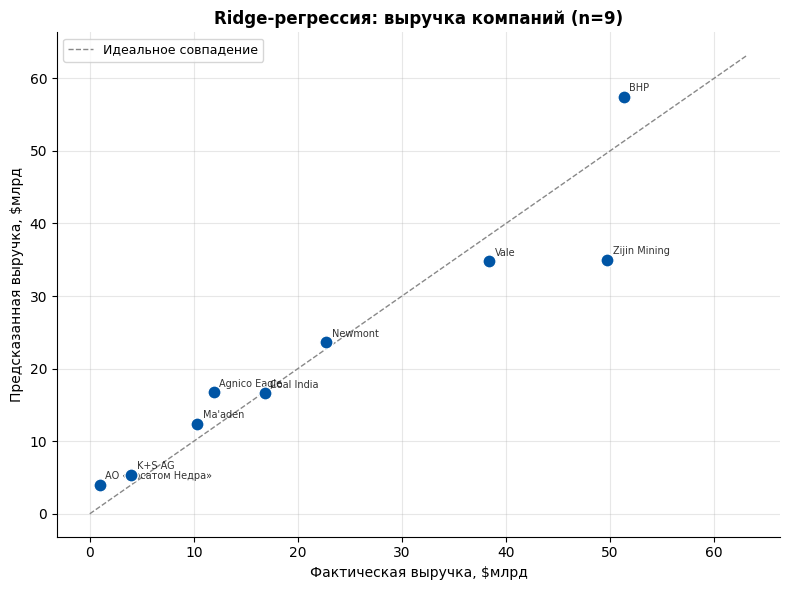

In [322]:
# --- 4. Регрессия ---
Xr = comp_df_model[['tech', 'ebitda', 'capex']].values
yr = comp_df_model['rev'].values

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0)),
])

# n < 15 → LeaveOneOut корректнее, чем 5-fold
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
r2_scores   = cross_val_score(pipe, Xr, yr, cv=loo, scoring='r2')
rmse_scores = -cross_val_score(pipe, Xr, yr, cv=loo, scoring='neg_root_mean_squared_error')

print(f"LOO CV R²:   {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"LOO CV RMSE: {rmse_scores.mean():.2f} $млрд")
print("  (n очень мало — метрики скорее декоративные)")

pipe.fit(Xr, yr)
coefs = pipe.named_steps['ridge'].coef_
print("\nКоэффициенты (стандартизованные):")
for f, c in zip(['tech', 'ebitda', 'capex'], coefs):
    print(f"  {f:<8}: {c:+.3f}")

# --- 5. Визуализация ---
fig, ax = plt.subplots(figsize=(8, 6))
y_pred = pipe.predict(Xr)
ax.scatter(yr, y_pred, s=90, color=BLUE, edgecolor='white', zorder=4)
lims = [0, max(yr.max(), y_pred.max()) * 1.1]
ax.plot(lims, lims, '--', color='#888', lw=1, label='Идеальное совпадение')
for name, x_, y_ in zip(comp_df_model['name'], yr, y_pred):
    ax.annotate(name.split('(')[0].strip(), (x_, y_),
                fontsize=7, xytext=(4, 4), textcoords='offset points', alpha=0.8)
ax.set_xlabel('Фактическая выручка, $млрд')
ax.set_ylabel('Предсказанная выручка, $млрд')
ax.set_title(f'Ridge-регрессия: выручка компаний (n={len(yr)})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

### 6.5. Обнаружение аномалий в профилях стран

IsolationForest ищет страны с **нетипичной структурой добычи** относительно остальных.
Это не «ошибка в данных», а именно выброс по профилю — например, страна с одной доминирующей
группой сырья, тогда как у большинства профиль разнообразный.

Топ-10 наиболее аномальных профилей:
        country     score  is_anom     prod_mt
         Mexico -0.521583       -1  182.638651
          China -0.517318       -1 8428.830342
   South Africa -0.495516       -1  359.631774
          Japan -0.482563       -1  154.982605
         Turkey -0.481712        1  375.914099
Korea (Rep. of) -0.474636        1  114.608557
            USA -0.455961        1 1586.670623
         Russia -0.445502        1 1239.820135
        Finland -0.435085        1   76.980188
         Brazil -0.434099        1  761.795022


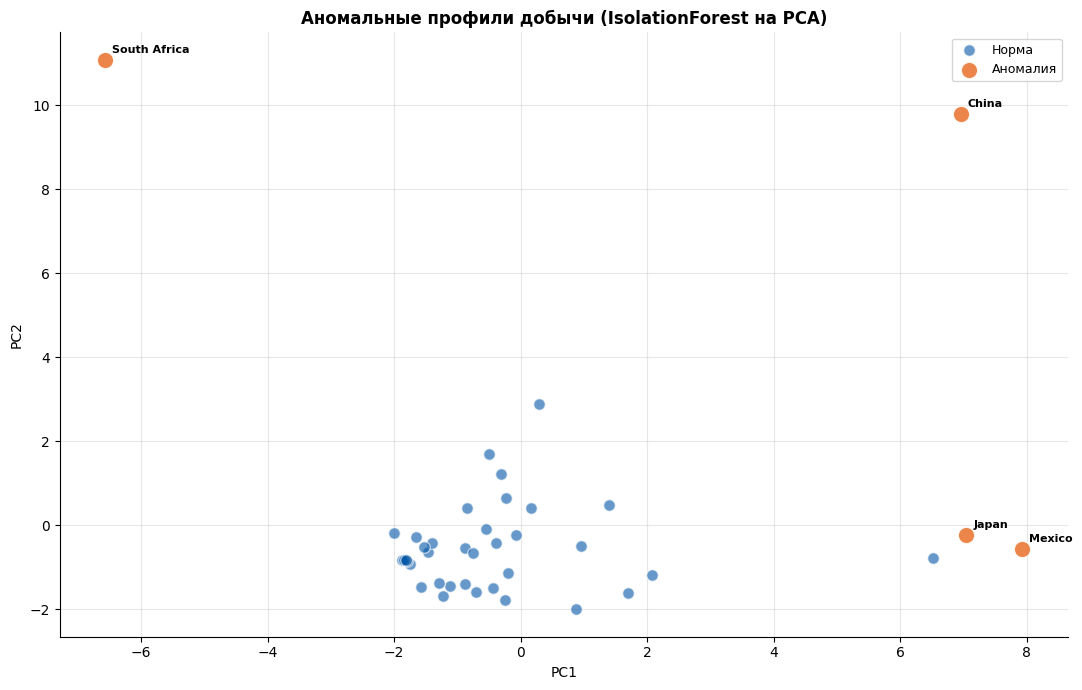

In [323]:
# 6.5. IsolationForest на профилях стран
iso = IsolationForest(contamination=0.1, random_state=RANDOM_STATE)
iso.fit(X_scaled)
scores = iso.score_samples(X_scaled)      # чем меньше — тем более аномально
pred = iso.predict(X_scaled)              # -1 = аномалия, +1 = норма

anom_df = pd.DataFrame({
    'country': countries,
    'score':   scores,
    'is_anom': pred,
    'prod_mt': [country_total.loc[country_total['country']==c, 'prod_mt'].values[0]
                if c in country_total['country'].values else np.nan for c in countries],
}).sort_values('score')

print("Топ-10 наиболее аномальных профилей:")
print(anom_df.head(10).to_string(index=False))

# Визуализация: PCA + цвет аномалий
fig, ax = plt.subplots(figsize=(11, 7))
normal = pred == 1
ax.scatter(X_pca[normal, 0], X_pca[normal, 1], s=70, color=BLUE,
           alpha=0.6, label='Норма', edgecolor='white', zorder=3)
ax.scatter(X_pca[~normal, 0], X_pca[~normal, 1], s=140, color=ACCENT,
           alpha=0.85, label='Аномалия', edgecolor='white', zorder=4)
for i, name in enumerate(countries):
    if not normal[i]:
        ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]),
                    fontsize=8, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')
ax.set_title('Аномальные профили добычи (IsolationForest на PCA)', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

In [324]:
# 7.1. Установка и стиль
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'seaborn'], check=False)

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Единый стиль под корпоративную палитру ноутбука
sns.set_theme(
    style='whitegrid',
    context='notebook',
    palette='muted',
    font='DejaVu Sans',
    rc={
        'axes.edgecolor': '#D0D7E3',
        'axes.labelcolor': '#333333',
        'axes.titlecolor': '#0055A5',
        'axes.titlesize': 12,
        'axes.titleweight': 'bold',
        'grid.color': '#D0D7E3',
        'grid.alpha': 0.6,
        'figure.facecolor': '#FFFFFF',
        'axes.facecolor': '#F5F7FA',
    }
)

# Именованные цвета для повторного использования
C_BLUE   = '#0055A5'
C_ACCENT = '#E8702A'
C_GREEN  = '#27AE60'
C_GRAY   = '#BDC3C7'
print("Seaborn готов, версия:", sns.__version__)

Seaborn готов, версия: 0.13.2


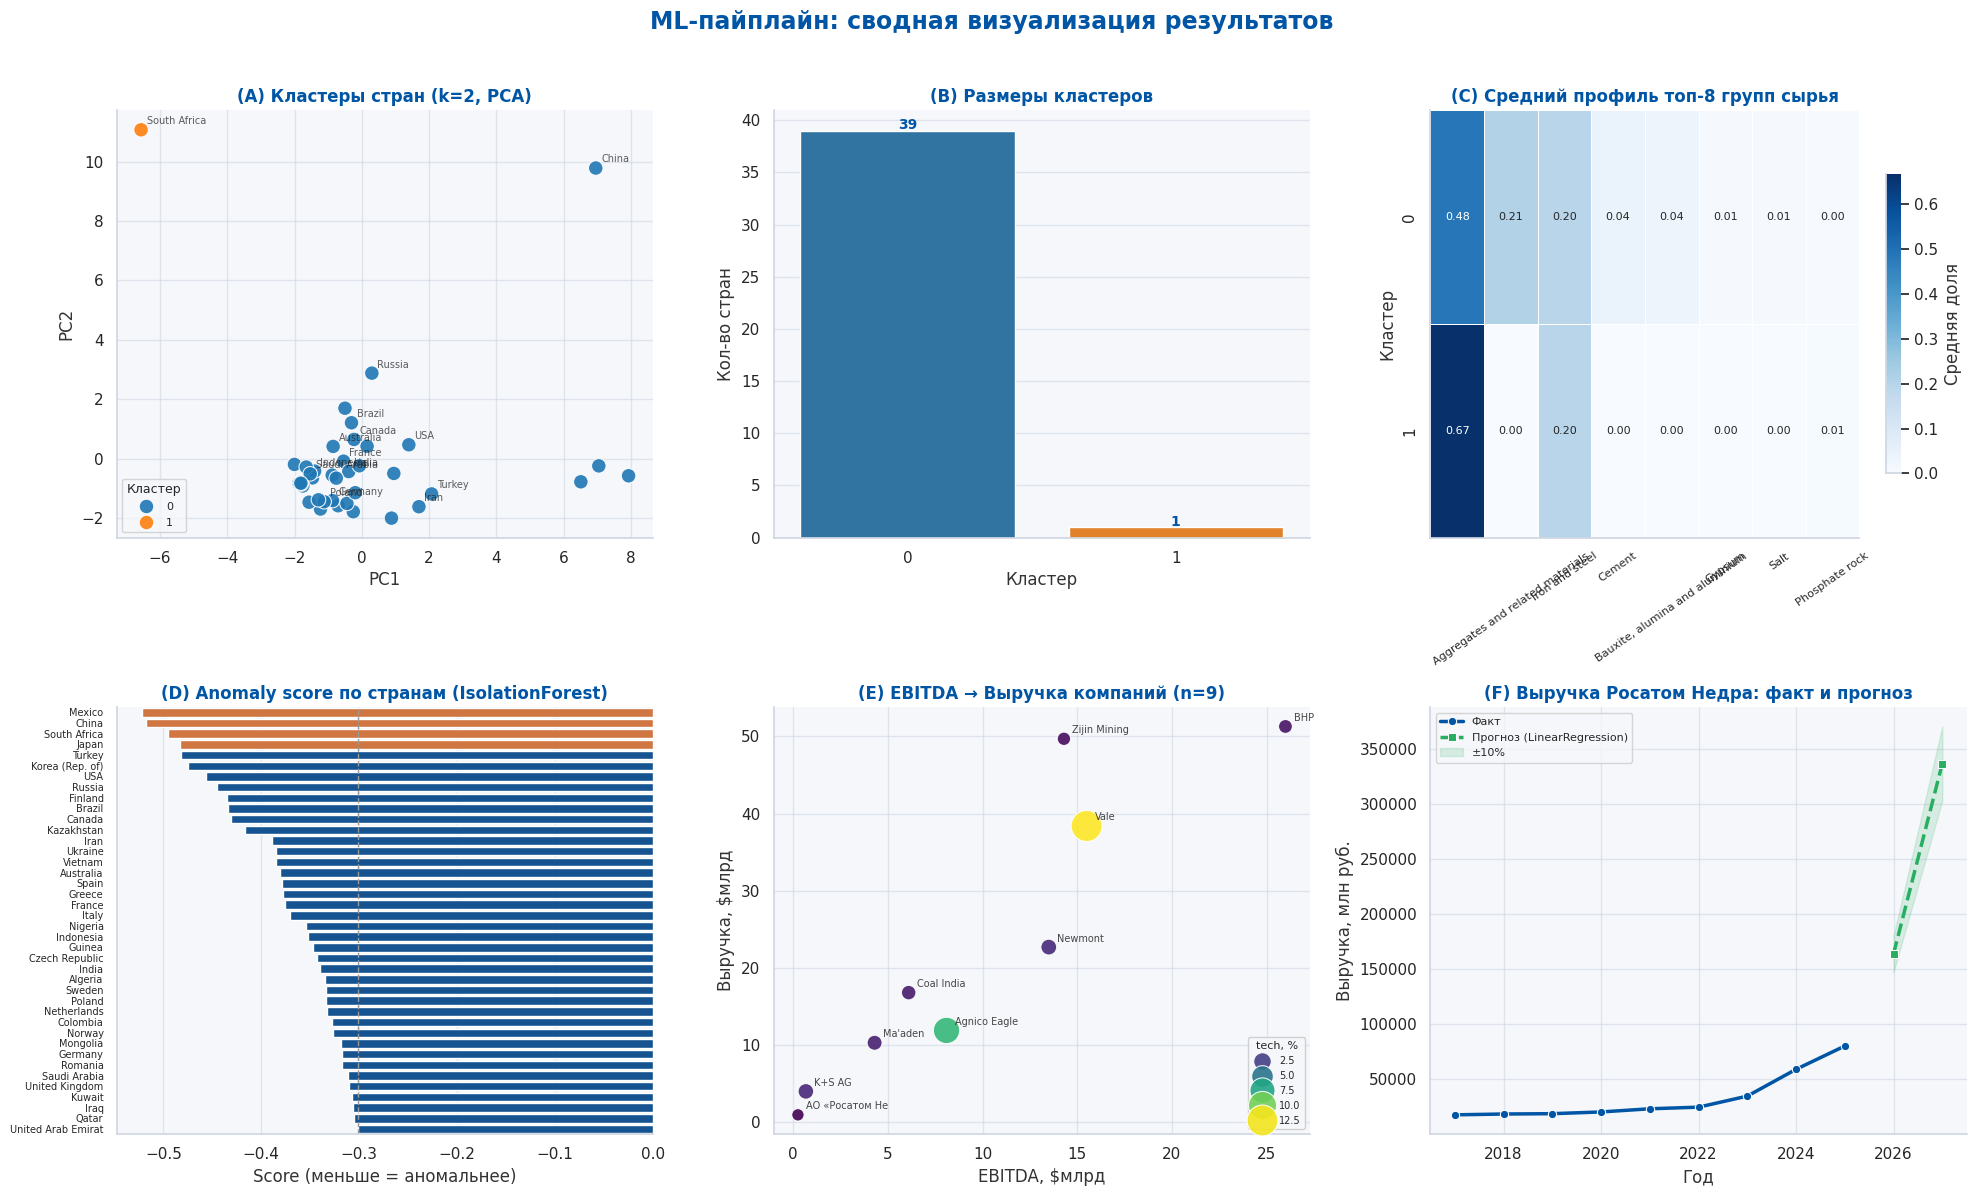

In [325]:
# 7.2. Сводный дашборд 2×3

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('ML-пайплайн: сводная визуализация результатов',
             fontsize=17, fontweight='bold', color=C_BLUE, y=0.995)

# ------------------------------------------------------------------
# (A) Кластеры в PCA-проекции (из блока 6.2)
# ------------------------------------------------------------------
ax = axes[0, 0]
palette = sns.color_palette('tab10', best_k)
cluster_series = pd.Series(labels, index=countries, name='cluster')

plot_df = pd.DataFrame({
    'pc1': X_pca[:, 0],
    'pc2': X_pca[:, 1],
    'cluster': [str(c) for c in labels],
    'country': countries,
})

sns.scatterplot(
    data=plot_df, x='pc1', y='pc2',
    hue='cluster', palette=palette,
    s=110, edgecolor='white', linewidth=0.8,
    ax=ax, alpha=0.9
)
# Подписи только для нескольких крупных стран, чтобы не зашуметь
highlight = set(country_total.head(15)['country'])
for _, r in plot_df.iterrows():
    if r['country'] in highlight:
        ax.annotate(r['country'], (r['pc1'], r['pc2']),
                    fontsize=7, alpha=0.75,
                    xytext=(4, 4), textcoords='offset points')
ax.set_title(f'(A) Кластеры стран (k={best_k}, PCA)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(title='Кластер', fontsize=8, title_fontsize=9, loc='best')

# ------------------------------------------------------------------
# (B) Размеры кластеров
# ------------------------------------------------------------------
ax = axes[0, 1]
sizes = pd.Series(labels).value_counts().sort_index()
sns.barplot(
    x=sizes.index.astype(str), y=sizes.values,
    palette=[palette[i] for i in sizes.index],
    ax=ax, edgecolor='white'
)
for i, v in enumerate(sizes.values):
    ax.text(i, v + 0.15, str(v), ha='center',
            fontsize=10, fontweight='bold', color=C_BLUE)
ax.set_title('(B) Размеры кластеров')
ax.set_xlabel('Кластер'); ax.set_ylabel('Кол-во стран')

# ------------------------------------------------------------------
# (C) Топ-10 профилей: тепловая карта средних долей по кластерам
# ------------------------------------------------------------------
ax = axes[0, 2]
top_groups = (profile.sum(axis=0).nlargest(8).index.tolist())
heat = profile.copy()
heat['cluster'] = labels
heat_mean = heat.groupby('cluster')[top_groups].mean()

sns.heatmap(
    heat_mean,
    cmap='Blues', annot=True, fmt='.2f',
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Средняя доля'},
    ax=ax, annot_kws={'fontsize': 8}
)
ax.set_title('(C) Средний профиль топ-8 групп сырья')
ax.set_xlabel(''); ax.set_ylabel('Кластер')
ax.tick_params(axis='x', rotation=35, labelsize=8)

# ------------------------------------------------------------------
# (D) Anomaly score (из блока 6.5) — горизонтальный бар
# ------------------------------------------------------------------
ax = axes[1, 0]
anom_plot = anom_df.copy()
anom_plot['short'] = anom_plot['country'].str.slice(0, 18)
anom_plot = anom_plot.sort_values('score')

sns.barplot(
    data=anom_plot, y='short', x='score',
    palette=['#E8702A' if a == -1 else C_BLUE for a in anom_plot['is_anom']],
    ax=ax, edgecolor='white'
)
ax.axvline(anom_plot.loc[anom_plot['is_anom'] == 1, 'score'].max(),
           color='#999', ls='--', lw=1)
ax.set_title('(D) Anomaly score по странам (IsolationForest)')
ax.set_xlabel('Score (меньше = аномальнее)')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7)

# ------------------------------------------------------------------
# (E) Компании: EBITDA vs Выручка (с цветом по tech-инвестициям)
# ------------------------------------------------------------------
ax = axes[1, 1]
cp = comp_df_model.copy()
cp['short'] = cp['name'].apply(lambda s: s.split('\n')[0].split('(')[0].strip()[:14])

sc = sns.scatterplot(
    data=cp, x='ebitda', y='rev',
    size='tech', sizes=(80, 500),
    hue='tech', palette='viridis',
    edgecolor='white', linewidth=0.8,
    ax=ax, alpha=0.9
)
for _, r in cp.iterrows():
    ax.annotate(r['short'], (r['ebitda'], r['rev']),
                fontsize=7, alpha=0.85,
                xytext=(6, 4), textcoords='offset points')
ax.set_title(f'(E) EBITDA → Выручка компаний (n={len(cp)})')
ax.set_xlabel('EBITDA, $млрд'); ax.set_ylabel('Выручка, $млрд')
# Легенда размера = tech%
handles, lbls = ax.get_legend_handles_labels()
ax.legend(title='tech, %', fontsize=7, title_fontsize=8,
          loc='lower right', framealpha=0.9)

# ------------------------------------------------------------------
# (F) Факт vs Прогноз выручки Недра
# ------------------------------------------------------------------
ax = axes[1, 2]
sns.lineplot(
    x=df_ts['year'], y=df_ts['rev'],
    marker='o', color=C_BLUE, linewidth=2.5,
    label='Факт', ax=ax
)
sns.lineplot(
    x=df_forecast['year'], y=df_forecast['rev_pred'],
    marker='s', color=C_GREEN, linewidth=2.5, linestyle='--',
    label=f'Прогноз ({best_name})', ax=ax
)
ax.fill_between(
    df_forecast['year'],
    df_forecast['rev_pred'] * 0.9,
    df_forecast['rev_pred'] * 1.1,
    color=C_GREEN, alpha=0.15, label='±10%'
)
ax.set_title('(F) Выручка Росатом Недра: факт и прогноз')
ax.set_xlabel('Год'); ax.set_ylabel('Выручка, млн руб.')
ax.legend(fontsize=8)

# ------------------------------------------------------------------
sns.despine(fig=fig, top=True, right=True)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

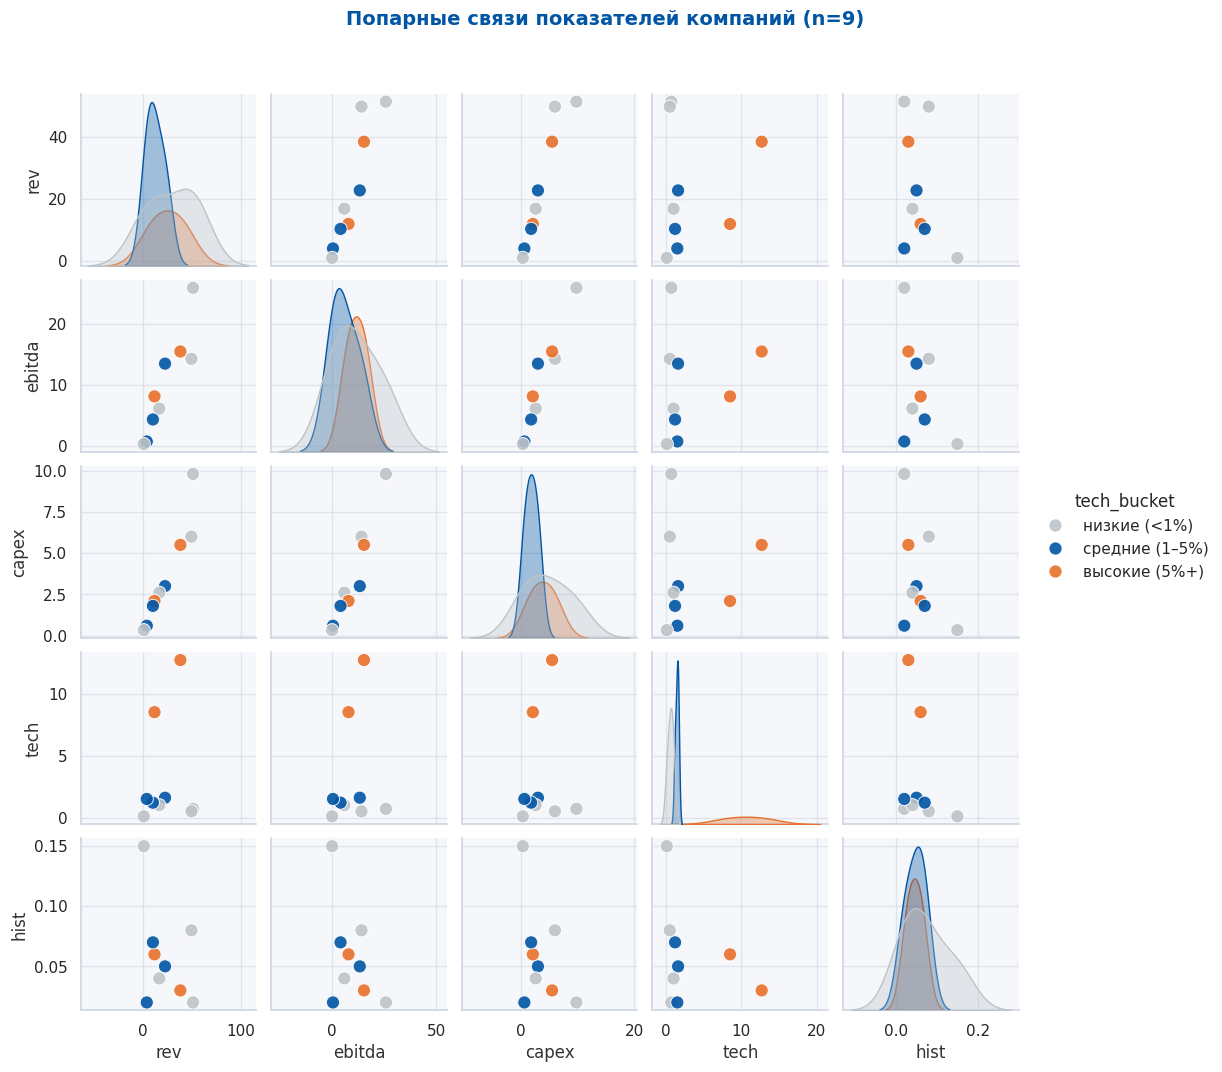

In [326]:
# 7.3. PairPlot: взаимосвязи показателей 10 компаний

pair_cols = ['rev', 'ebitda', 'capex', 'tech', 'hist']
pair_df = comp_df_model[pair_cols].copy()
pair_df['tech_bucket'] = pd.cut(
    pair_df['tech'],
    bins=[-0.01, 1, 5, 15],
    labels=['низкие (<1%)', 'средние (1–5%)', 'высокие (5%+)']
)

g = sns.pairplot(
    pair_df,
    hue='tech_bucket',
    palette={'низкие (<1%)': C_GRAY,
             'средние (1–5%)': C_BLUE,
             'высокие (5%+)': C_ACCENT},
    diag_kind='kde',
    corner=False,
    plot_kws=dict(s=90, edgecolor='white', linewidth=0.7, alpha=0.9),
    diag_kws=dict(fill=True, alpha=0.35),
    height=2.1
)
g.fig.suptitle('Попарные связи показателей компаний (n=%d)' % len(pair_df),
               fontsize=14, fontweight='bold', color=C_BLUE, y=1.02)
g.fig.subplots_adjust(top=0.94)
plt.show()

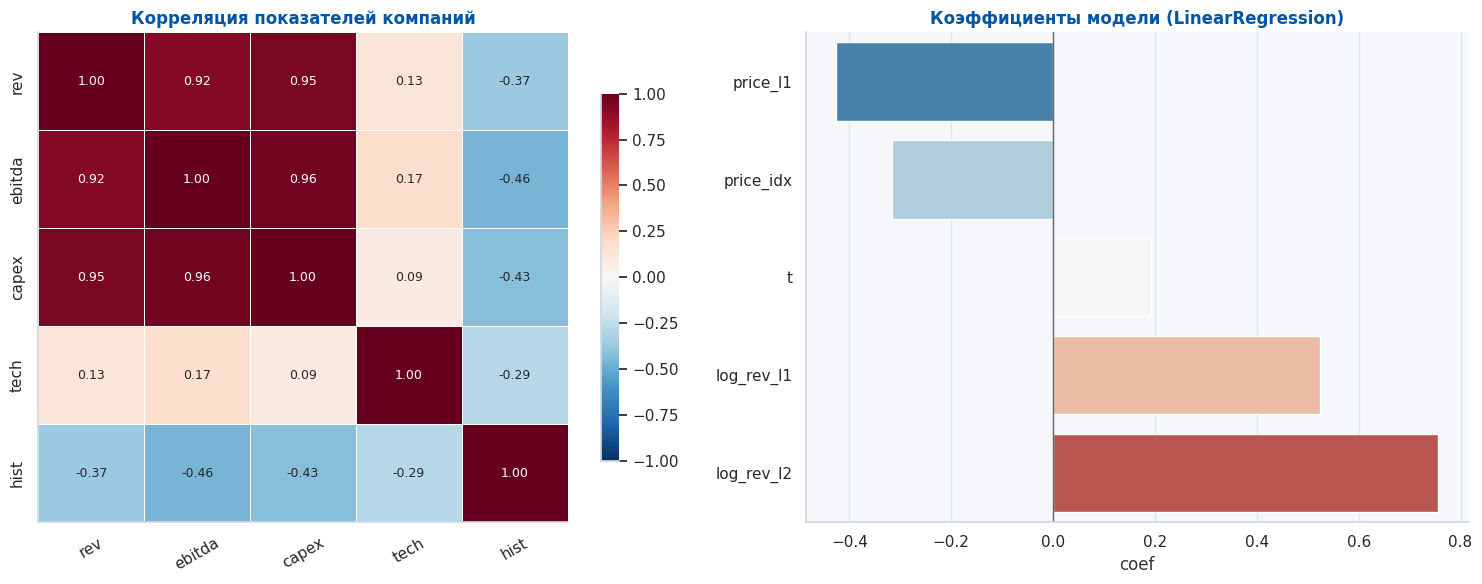

In [327]:
# 7.4. Корреляционная матрица признаков компаний + важность фичей модели

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- корреляция ---
ax = axes[0]
corr = comp_df_model[['rev', 'ebitda', 'capex', 'tech', 'hist']].corr()
sns.heatmap(
    corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.75}, ax=ax, annot_kws={'fontsize': 9}
)
ax.set_title('Корреляция показателей компаний')
ax.tick_params(axis='x', rotation=30)

# --- важность признаков (если модель — дерево) ---
ax = axes[1]
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_,
                    index=feature_cols).sort_values()
    sns.barplot(x=imp.values, y=imp.index, palette='Blues_d',
                ax=ax, edgecolor='white')
    for i, v in enumerate(imp.values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
    ax.set_title(f'Важность признаков ({best_name})')
    ax.set_xlabel('Importance'); ax.set_ylabel('')
else:
    # если лучшая модель линейная — показываем коэффициенты
    coefs_series = pd.Series(best_model.coef_, index=feature_cols).sort_values()
    sns.barplot(x=coefs_series.values, y=coefs_series.index,
                palette='RdBu_r', ax=ax, edgecolor='white')
    ax.axvline(0, color='#666', lw=1)
    ax.set_title(f'Коэффициенты модели ({best_name})')
    ax.set_xlabel('coef'); ax.set_ylabel('')

sns.despine(fig=fig, top=True, right=True)
plt.tight_layout()
plt.show()

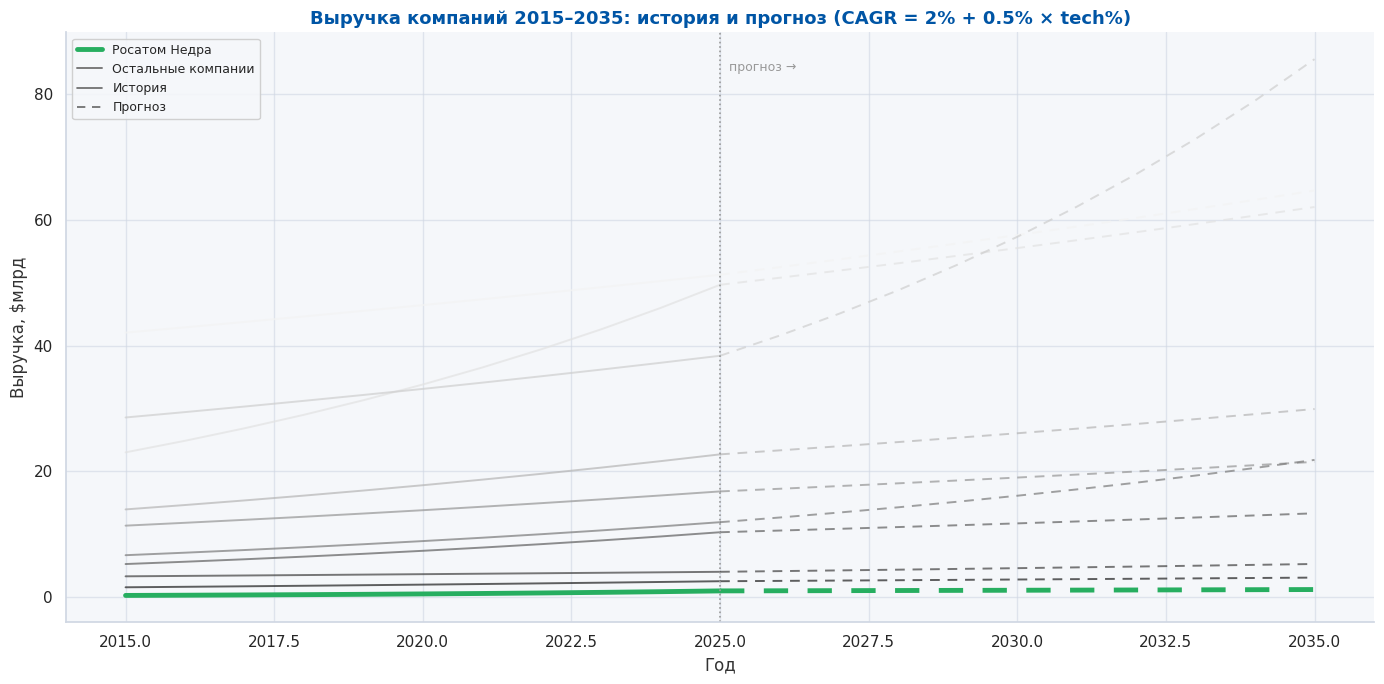

In [328]:
# 7.5. Seaborn-версия прогноза выручки (та же CAGR-модель, что в блоке 5)

years_hist = list(range(2015, 2026))
years_fut  = list(range(2025, 2036))

rows = []
for name, d in companies.items():
    short = name.split('\n')[0].split('(')[0].strip()
    is_nedra = 'Росатом' in short
    cagr = BASE + MULT * d['tech']

    # историческая реконструкция (как в блоке 5)
    for y in years_hist:
        rows.append({
            'name': short, 'year': y,
            'rev': d['rev'] / (1 + d['hist']) ** (2025 - y),
            'phase': 'история', 'is_nedra': is_nedra,
        })
    # прогноз
    for y in years_fut:
        rows.append({
            'name': short, 'year': y,
            'rev': d['rev'] * (1 + cagr) ** (y - 2025),
            'phase': 'прогноз', 'is_nedra': is_nedra,
        })

forecast_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(14, 7))

# все компании — серые, Росатом Недра — зелёный
sns.lineplot(
    data=forecast_df[~forecast_df['is_nedra']],
    x='year', y='rev',
    hue='name', style='phase',
    palette='Greys',
    dashes={'история': '', 'прогноз': (5, 4)},
    linewidth=1.4, ax=ax, legend=False, alpha=0.7
)
sns.lineplot(
    data=forecast_df[forecast_df['is_nedra']],
    x='year', y='rev',
    hue='name', style='phase',
    palette={forecast_df.loc[forecast_df['is_nedra'], 'name'].iloc[0]: C_GREEN},
    dashes={'история': '', 'прогноз': (5, 4)},
    linewidth=3.5, ax=ax, legend=True
)

ax.axvline(2025, color='#999', ls=':', lw=1.2)
ax.text(2025.15, ax.get_ylim()[1] * 0.95, 'прогноз →',
        fontsize=9, color='#999', va='top')

ax.set_title('Выручка компаний 2015–2035: история и прогноз (CAGR = 2% + 0.5% × tech%)',
             fontsize=13, fontweight='bold', color=C_BLUE)
ax.set_xlabel('Год'); ax.set_ylabel('Выручка, $млрд')

# Кастомная легенда
legend_handles = [
    mpl.lines.Line2D([], [], color=C_GREEN, lw=3.5, label='Росатом Недра'),
    mpl.lines.Line2D([], [], color='#7a7a7a', lw=1.4, label='Остальные компании'),
    mpl.lines.Line2D([], [], color='#666', lw=1.2, ls='-', label='История'),
    mpl.lines.Line2D([], [], color='#666', lw=1.2, ls=(0, (5, 4)), label='Прогноз'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper left', framealpha=0.9)

sns.despine(fig=fig, top=True, right=True)
plt.tight_layout()
plt.show()

### 7.6. Итоги ML-пайплайна

**Что получилось:**
- KMeans разбил топ-40 стран на однородные группы по сырьевому профилю (лучшее k — по silhouette).
- TimeSeriesSplit + сравнение 4 моделей дало прогноз выручки Недра на 2026–2027 с RMSE на валидации.
- IsolationForest выделил страны с нетипичной структурой добычи.
- Ridge показал, какие факторы компаний сильнее связаны с выручкой (с оговоркой про n=10).

**Ограничения и что улучшить дальше:**

4. Гиперпараметры моделей сейчас дефолтные — добавить `GridSearchCV` / `Optuna`.
5. Добавить `MLflow` или `Weights & Biases` для трекинга экспериментов.